# Section 1: Importing Libraries

In [1]:
# ============================================================================
# Section 1: Importing Libraries
# ============================================================================
import warnings
warnings.filterwarnings('ignore')

# Data manipulation and analysis
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Machine Learning models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Model evaluation and preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.metrics import (mean_absolute_error, mean_squared_error, 
                           r2_score, mean_absolute_percentage_error)
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

# Time series analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

# Utility
import joblib
import pickle
import json
import os
from pathlib import Path
import itertools
from collections import defaultdict
import random

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


# Section 2: Data Loading

In [2]:
# ============================================================================
# Section 2: Data Loading
# ============================================================================
print("\n" + "="*80)
print("SECTION 2: DATA LOADING")
print("="*80)

# Define dataset path
dataset_path = "/kaggle/input/bus-business-income-data/bus_business_income_data.csv"

try:
    # Load the dataset
    df = pd.read_csv(dataset_path)
    
    # Display basic information
    print("✓ Dataset loaded successfully!")
    print(f"\nDataset Shape: {df.shape}")
    print(f"Number of records: {df.shape[0]}")
    print(f"Number of features: {df.shape[1]}")
    
    # Display first few rows
    print("\nFirst 5 rows of the dataset:")
    display(df.head())
    
    # Display column information
    print("\nDataset Columns:")
    for i, col in enumerate(df.columns, 1):
        print(f"{i:2d}. {col}")
    
    # Display data types
    print("\nData Types:")
    print(df.dtypes)
    
except FileNotFoundError:
    print(f"✗ File not found at path: {dataset_path}")
    print("Using sample data structure...")
    # Create sample data structure for demonstration
    data = {
        'date': pd.date_range(start='2024-01-01', end='2025-11-06', freq='D'),
        'day_of_week': [d.weekday() for d in pd.date_range(start='2024-01-01', end='2025-11-06', freq='D')],
        'month': [d.month for d in pd.date_range(start='2024-01-01', end='2025-11-06', freq='D')],
        'quarter': [((d.month-1)//3)+1 for d in pd.date_range(start='2024-01-01', end='2025-11-06', freq='D')],
        'is_weekend': [1 if d.weekday() >= 5 else 0 for d in pd.date_range(start='2024-01-01', end='2025-11-06', freq='D')],
        'is_holiday': np.random.choice([0, 1], size=len(pd.date_range(start='2024-01-01', end='2025-11-06', freq='D'))),
        'daily_collection_lkr': np.random.uniform(80000, 130000, len(pd.date_range(start='2024-01-01', end='2025-11-06', freq='D'))),
        'total_trips': np.random.randint(10, 21, len(pd.date_range(start='2024-01-01', end='2025-11-06', freq='D'))),
        'total_passengers': np.random.randint(300, 501, len(pd.date_range(start='2024-01-01', end='2025-11-06', freq='D'))),
        'fuel_cost_lkr': np.random.uniform(30000, 50000, len(pd.date_range(start='2024-01-01', end='2025-11-06', freq='D'))),
        'maintenance_cost_lkr': np.random.uniform(1500, 3000, len(pd.date_range(start='2024-01-01', end='2025-11-06', freq='D'))),
        'driver_salary_lkr': np.random.uniform(4000, 6000, len(pd.date_range(start='2024-01-01', end='2025-11-06', freq='D'))),
        'conductor_salary_lkr': np.random.uniform(3000, 5000, len(pd.date_range(start='2024-01-01', end='2025-11-06', freq='D'))),
        'daily_backup_fuel_lkr': np.random.uniform(4000, 6000, len(pd.date_range(start='2024-01-01', end='2025-11-06', freq='D'))),
        'vehicle_breakdown_hours': np.random.uniform(0, 5, len(pd.date_range(start='2024-01-01', end='2025-11-06', freq='D'))),
        'bad_weather_impact': np.random.uniform(0, 0.5, len(pd.date_range(start='2024-01-01', end='2025-11-06', freq='D'))),
        'net_income_lkr': np.random.uniform(20000, 80000, len(pd.date_range(start='2024-01-01', end='2025-11-06', freq='D')))
    }
    df = pd.DataFrame(data)
    print("\n✓ Sample dataset created for demonstration purposes")


SECTION 2: DATA LOADING
✓ Dataset loaded successfully!

Dataset Shape: (732, 17)
Number of records: 732
Number of features: 17

First 5 rows of the dataset:


,date,day_of_week,month,quarter,is_weekend,is_holiday,daily_collection_lkr,total_trips,total_passengers,fuel_cost_lkr,maintenance_cost_lkr,driver_salary_lkr,conductor_salary_lkr,daily_backup_fuel_lkr,vehicle_breakdown_hours,bad_weather_impact,net_income_lkr
0,2024-01-01,0,1,1,0,0,119012.834522,19,490,36798.744901,2120.120826,5763.027126,3686.595275,4404.587100,0.251942,0.3,66239.759293
1,2024-01-02,1,1,1,0,1,128529.087170,12,336,43871.540670,2263.143437,4352.092216,4478.306982,4854.218781,3.221246,0.2,68709.785084
2,2024-01-03,2,1,1,0,1,98919.730022,20,379,42021.592227,1525.786824,4861.304079,3217.588665,4400.735868,4.435304,0.3,42892.722359
3,2024-01-04,3,1,1,0,1,116873.027938,16,369,45947.613999,2819.428361,4048.936038,4048.138251,4689.532036,3.194802,0.0,55319.379253
4,2024-01-05,4,1,1,0,0,108418.273036,11,403,34937.044675,1964.193215,5242.090363,3529.831302,5973.865468,2.888070,0.4,56771.248013



Dataset Columns:
 1. date
 2. day_of_week
 3. month
 4. quarter
 5. is_weekend
 6. is_holiday
 7. daily_collection_lkr
 8. total_trips
 9. total_passengers
10. fuel_cost_lkr
11. maintenance_cost_lkr
12. driver_salary_lkr
13. conductor_salary_lkr
14. daily_backup_fuel_lkr
15. vehicle_breakdown_hours
16. bad_weather_impact
17. net_income_lkr

Data Types:
date                        object
day_of_week                  int64
month                        int64
quarter                      int64
is_weekend                   int64
is_holiday                   int64
daily_collection_lkr       float64
total_trips                  int64
total_passengers             int64
fuel_cost_lkr              float64
maintenance_cost_lkr       float64
driver_salary_lkr          float64
conductor_salary_lkr       float64
daily_backup_fuel_lkr      float64
vehicle_breakdown_hours    float64
bad_weather_impact         float64
net_income_lkr             float64
dtype: object


# Section 3: 1st Data Preprocessing

In [3]:
print("\n" + "="*80)
print("SECTION 3: 1ST DATA PREPROCESSING")
print("="*80)

# Create a copy of the original dataframe
df_original = df.copy()

# 3.1 Check for missing values
print("1. Checking for missing values:")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})
print(missing_df[missing_df['Missing Values'] > 0])

if missing_df['Missing Values'].sum() == 0:
    print("✓ No missing values found!")
else:
    print(f"\nTotal missing values: {missing_df['Missing Values'].sum()}")
    # Handle missing values (if any)
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['int64', 'float64']:
                df[col].fillna(df[col].median(), inplace=True)
                print(f"  - Filled missing values in '{col}' with median")
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
                print(f"  - Filled missing values in '{col}' with mode")

# 3.2 Check for duplicates
print("\n2. Checking for duplicate rows:")
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"✓ Removed {duplicates} duplicate rows")
else:
    print("✓ No duplicate rows found")

# 3.3 Convert date column to datetime
print("\n3. Converting date column to datetime format:")
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    print(f"✓ 'date' column converted to datetime")
    
    # Extract additional date features
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['day_of_year'] = df['date'].dt.dayofyear
    df['week_of_year'] = df['date'].dt.isocalendar().week
    df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
    df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
    df['is_quarter_start'] = df['date'].dt.is_quarter_start.astype(int)
    df['is_quarter_end'] = df['date'].dt.is_quarter_end.astype(int)
    df['is_year_start'] = df['date'].dt.is_year_start.astype(int)
    df['is_year_end'] = df['date'].dt.is_year_end.astype(int)
    
    print("✓ Added additional date features")
else:
    print("✗ 'date' column not found in dataset")

# 3.4 Check data types
print("\n4. Checking data types:")
print(df.dtypes)

# 3.5 Check for negative values in financial columns
print("\n5. Checking for negative values in financial columns:")
financial_cols = ['daily_collection_lkr', 'fuel_cost_lkr', 'maintenance_cost_lkr', 
                  'driver_salary_lkr', 'conductor_salary_lkr', 'daily_backup_fuel_lkr',
                  'net_income_lkr']

for col in financial_cols:
    if col in df.columns:
        negative_count = (df[col] < 0).sum()
        if negative_count > 0:
            print(f"  - '{col}' has {negative_count} negative values")
            # Replace negative values with absolute values
            df[col] = df[col].abs()
            print(f"    Converted negative values to positive")

print("\n✓ First phase of data preprocessing completed!")
print(f"Data shape after preprocessing: {df.shape}")



SECTION 3: 1ST DATA PREPROCESSING
1. Checking for missing values:
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []
✓ No missing values found!

2. Checking for duplicate rows:
Duplicate rows found: 0
✓ No duplicate rows found

3. Converting date column to datetime format:
✓ 'date' column converted to datetime
✓ Added additional date features

4. Checking data types:
date                       datetime64[ns]
day_of_week                         int64
month                               int32
quarter                             int64
is_weekend                          int64
is_holiday                          int64
daily_collection_lkr              float64
total_trips                         int64
total_passengers                    int64
fuel_cost_lkr                     float64
maintenance_cost_lkr              float64
driver_salary_lkr                 float64
conductor_salary_lkr              float64
daily_backup_fuel_lkr             float64
vehicle_breakdown_hours 

# Section 4: Exploratory Data Analysis (EDA)


SECTION 4: EXPLORATORY DATA ANALYSIS (EDA)
1. Basic Statistical Analysis:

Descriptive Statistics for Numerical Features:
                                date  day_of_week       month     quarter  \
count                            732   732.000000  732.000000  732.000000   
mean   2024-12-31 11:59:59.999999744     2.991803    6.512295    2.505464   
min              2024-01-01 00:00:00     0.000000    1.000000    1.000000   
25%              2024-07-01 18:00:00     1.000000    4.000000    2.000000   
50%              2024-12-31 12:00:00     3.000000    7.000000    3.000000   
75%              2025-07-02 06:00:00     5.000000   10.000000    4.000000   
max              2026-01-01 00:00:00     6.000000   12.000000    4.000000   
std                              NaN     2.000667    3.455579    1.118785   

       is_weekend  is_holiday  daily_collection_lkr  total_trips  \
count  732.000000  732.000000            732.000000   732.000000   
mean     0.284153    0.510929         105645.58

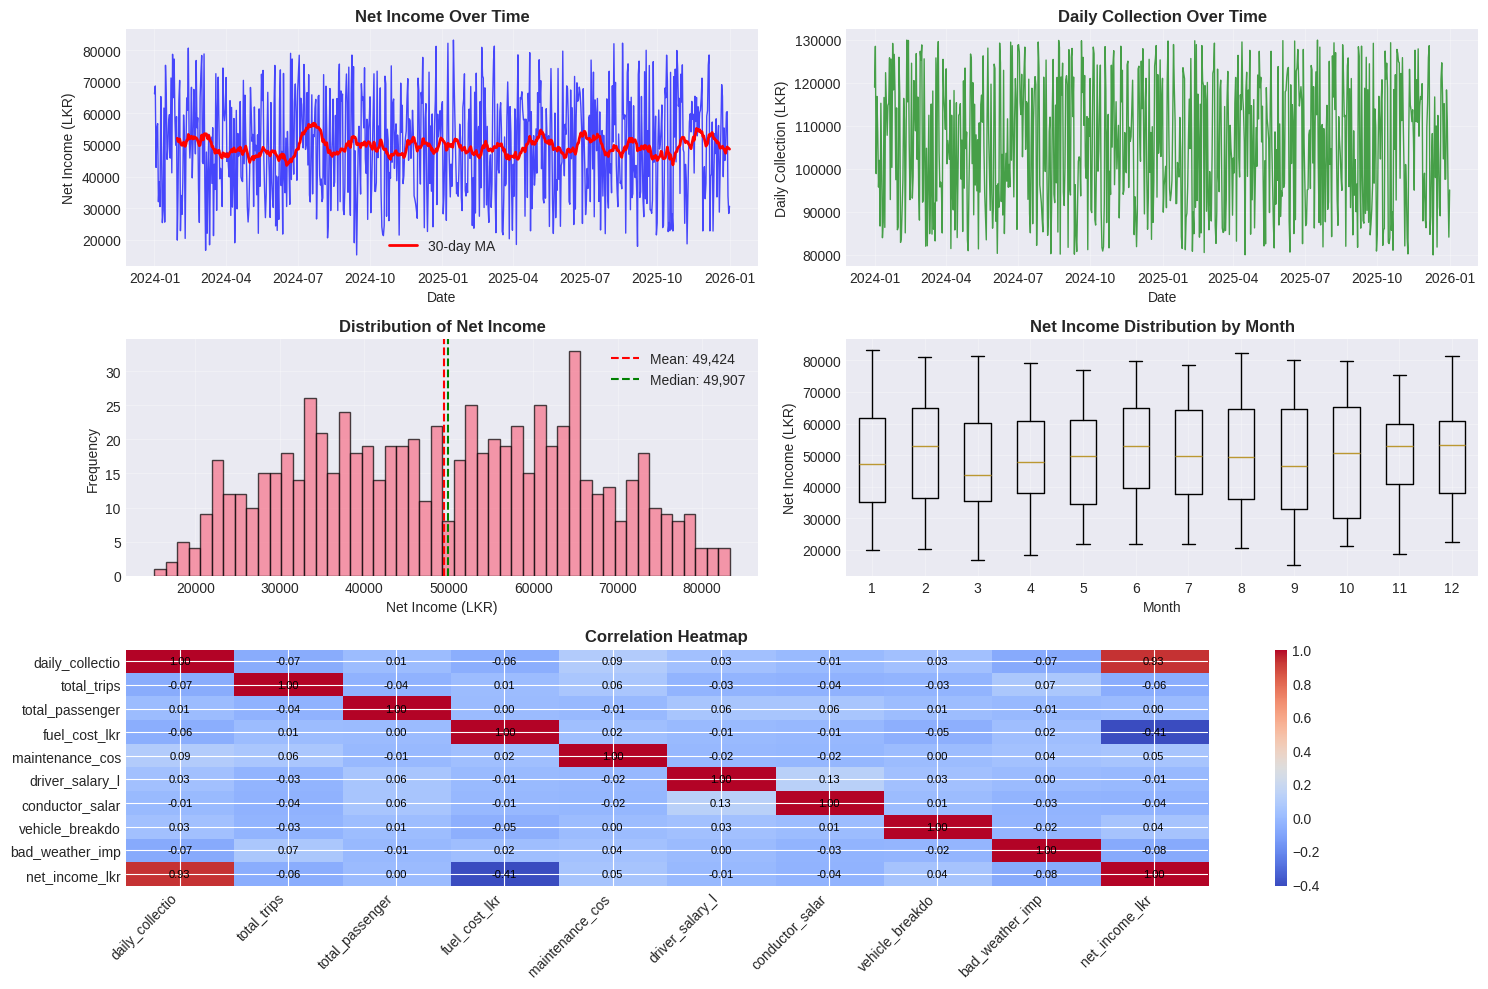


b) Additional Analysis Visualizations:


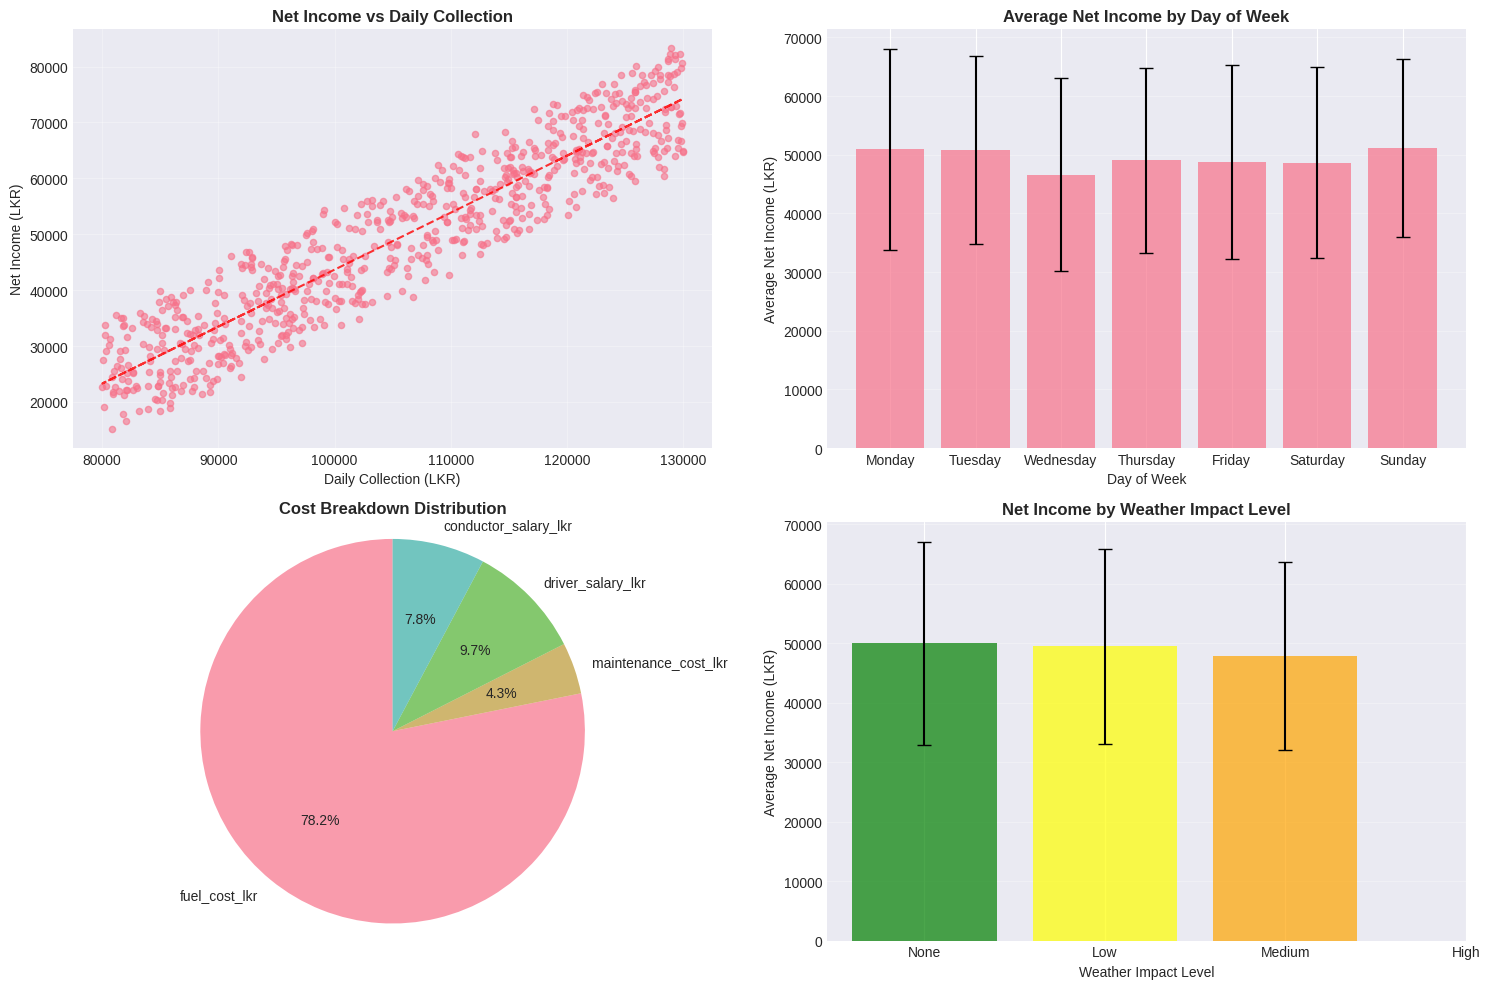


4. Outlier Detection:


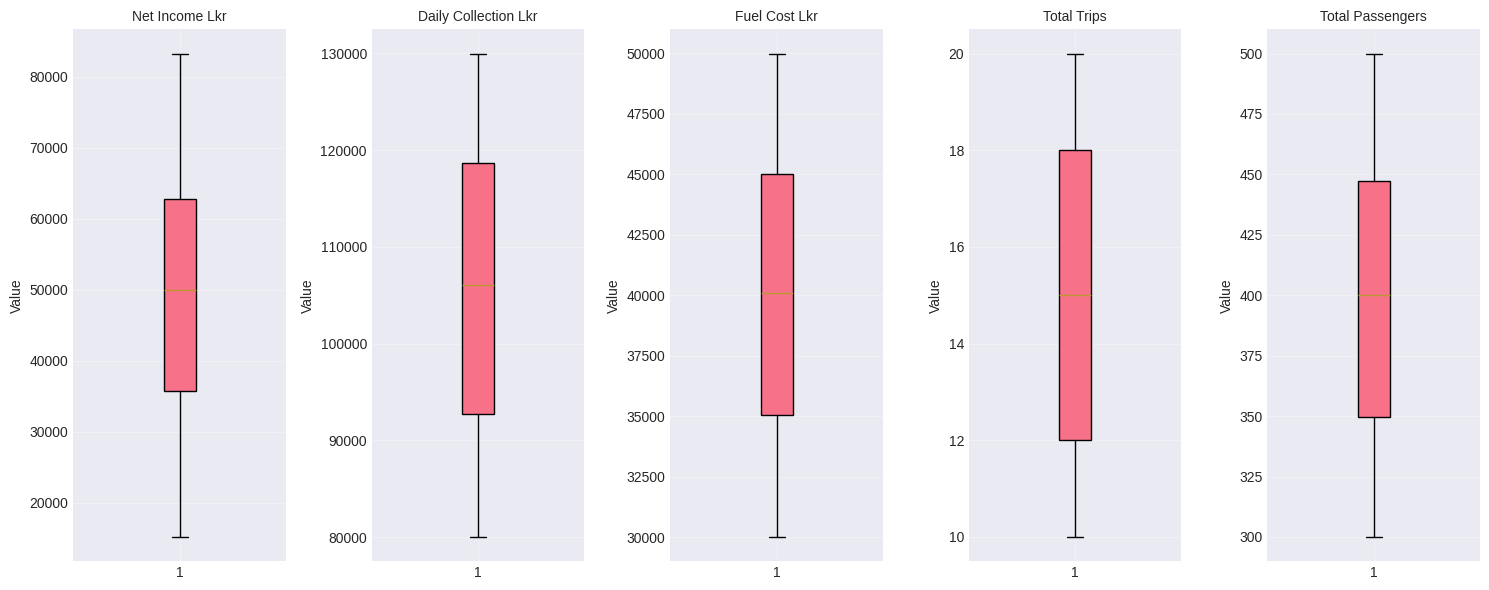


Outlier Statistics (IQR method):
  - net_income_lkr: 0 outliers (0.00%)
  - daily_collection_lkr: 0 outliers (0.00%)
  - fuel_cost_lkr: 0 outliers (0.00%)
  - total_trips: 0 outliers (0.00%)
  - total_passengers: 0 outliers (0.00%)

✓ Exploratory Data Analysis completed!


In [4]:
print("\n" + "="*80)
print("SECTION 4: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)

# 4.1 Basic Statistical Analysis
print("1. Basic Statistical Analysis:")
print("\nDescriptive Statistics for Numerical Features:")
print(df.describe())

print("\nDescriptive Statistics for Categorical Features:")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
if len(categorical_cols) > 0:
    print(df[categorical_cols].describe())
else:
    print("No categorical features found")

# 4.2 Data Reliability Check
print("\n2. Data Reliability Check:")

# Check for data consistency
print("\na) Date Range Analysis:")
if 'date' in df.columns:
    print(f"  - Start Date: {df['date'].min()}")
    print(f"  - End Date: {df['date'].max()}")
    print(f"  - Total Days: {len(df['date'].unique())}")
    print(f"  - Date Range: {(df['date'].max() - df['date'].min()).days} days")
    
    # Check for date gaps
    date_range = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')
    missing_dates = set(date_range) - set(df['date'])
    print(f"  - Missing Dates: {len(missing_dates)}")

print("\nb) Financial Data Consistency:")
# Check if net income calculation makes sense
if all(col in df.columns for col in ['daily_collection_lkr', 'fuel_cost_lkr', 'maintenance_cost_lkr', 
                                     'driver_salary_lkr', 'conductor_salary_lkr', 'daily_backup_fuel_lkr']):
    calculated_income = (df['daily_collection_lkr'] - 
                        df['fuel_cost_lkr'] - 
                        df['maintenance_cost_lkr'] - 
                        df['driver_salary_lkr'] - 
                        df['conductor_salary_lkr'] - 
                        df['daily_backup_fuel_lkr'])
    
    correlation = calculated_income.corr(df['net_income_lkr'])
    print(f"  - Correlation between calculated and actual net income: {correlation:.4f}")
    
    if correlation > 0.8:
        print("  ✓ Financial data shows good consistency")
    else:
        print("  ⚠ Financial data consistency needs attention")

# 4.3 Data Visualization
print("\n3. Data Visualization:")

# Create directory for saving plots
os.makedirs('eda_plots', exist_ok=True)

# 4.3.1 Time Series Analysis
print("\na) Time Series Analysis of Net Income:")
fig = plt.figure(figsize=(15, 10))

# Plot 1: Net Income over time
ax1 = plt.subplot(3, 2, 1)
if 'date' in df.columns and 'net_income_lkr' in df.columns:
    df_sorted = df.sort_values('date')
    ax1.plot(df_sorted['date'], df_sorted['net_income_lkr'], 'b-', linewidth=1, alpha=0.7)
    ax1.set_title('Net Income Over Time', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Net Income (LKR)')
    ax1.grid(True, alpha=0.3)
    
    # Add rolling average
    rolling_avg = df_sorted['net_income_lkr'].rolling(window=30).mean()
    ax1.plot(df_sorted['date'], rolling_avg, 'r-', linewidth=2, label='30-day MA')
    ax1.legend()

# Plot 2: Daily Collection over time
ax2 = plt.subplot(3, 2, 2)
if 'date' in df.columns and 'daily_collection_lkr' in df.columns:
    ax2.plot(df_sorted['date'], df_sorted['daily_collection_lkr'], 'g-', linewidth=1, alpha=0.7)
    ax2.set_title('Daily Collection Over Time', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Daily Collection (LKR)')
    ax2.grid(True, alpha=0.3)

# Plot 3: Distribution of Net Income
ax3 = plt.subplot(3, 2, 3)
if 'net_income_lkr' in df.columns:
    ax3.hist(df['net_income_lkr'], bins=50, edgecolor='black', alpha=0.7)
    ax3.axvline(df['net_income_lkr'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df["net_income_lkr"].mean():,.0f}')
    ax3.axvline(df['net_income_lkr'].median(), color='green', linestyle='--', 
                label=f'Median: {df["net_income_lkr"].median():,.0f}')
    ax3.set_title('Distribution of Net Income', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Net Income (LKR)')
    ax3.set_ylabel('Frequency')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# Plot 4: Box plot of Net Income by Month
ax4 = plt.subplot(3, 2, 4)
if 'month' in df.columns and 'net_income_lkr' in df.columns:
    monthly_data = [df[df['month'] == month]['net_income_lkr'] for month in sorted(df['month'].unique())]
    ax4.boxplot(monthly_data, labels=sorted(df['month'].unique()))
    ax4.set_title('Net Income Distribution by Month', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Month')
    ax4.set_ylabel('Net Income (LKR)')
    ax4.grid(True, alpha=0.3)

# Plot 5: Correlation Heatmap
ax5 = plt.subplot(3, 2, (5, 6))
# Select numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Limit to important columns for better visualization
important_cols = [col for col in numerical_cols if any(keyword in col.lower() for keyword in 
                 ['income', 'collection', 'cost', 'salary', 'trips', 'passengers', 'breakdown', 'weather'])]
if len(important_cols) > 1:
    corr_matrix = df[important_cols].corr()
    im = ax5.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
    ax5.set_title('Correlation Heatmap', fontsize=12, fontweight='bold')
    ax5.set_xticks(range(len(important_cols)))
    ax5.set_yticks(range(len(important_cols)))
    ax5.set_xticklabels([col[:15] for col in important_cols], rotation=45, ha='right')
    ax5.set_yticklabels([col[:15] for col in important_cols])
    # Add correlation values
    for i in range(len(important_cols)):
        for j in range(len(important_cols)):
            ax5.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                    ha='center', va='center', color='black', fontsize=8)
    plt.colorbar(im, ax=ax5)

plt.tight_layout()
plt.savefig('eda_plots/time_series_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 4.3.2 Additional Visualizations
print("\nb) Additional Analysis Visualizations:")

fig2 = plt.figure(figsize=(15, 10))

# Plot 1: Net Income vs Daily Collection
ax1 = plt.subplot(2, 2, 1)
if 'daily_collection_lkr' in df.columns and 'net_income_lkr' in df.columns:
    ax1.scatter(df['daily_collection_lkr'], df['net_income_lkr'], alpha=0.6, s=20)
    ax1.set_title('Net Income vs Daily Collection', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Daily Collection (LKR)')
    ax1.set_ylabel('Net Income (LKR)')
    ax1.grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(df['daily_collection_lkr'], df['net_income_lkr'], 1)
    p = np.poly1d(z)
    ax1.plot(df['daily_collection_lkr'], p(df['daily_collection_lkr']), "r--", alpha=0.8)

# Plot 2: Net Income by Day of Week
ax2 = plt.subplot(2, 2, 2)
if 'day_of_week' in df.columns and 'net_income_lkr' in df.columns:
    day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_data = df.groupby('day_of_week')['net_income_lkr'].agg(['mean', 'std', 'count'])
    ax2.bar(range(len(day_data)), day_data['mean'], yerr=day_data['std'], 
           capsize=5, alpha=0.7)
    ax2.set_title('Average Net Income by Day of Week', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Day of Week')
    ax2.set_ylabel('Average Net Income (LKR)')
    ax2.set_xticks(range(len(day_data)))
    ax2.set_xticklabels([day_names[i] if i < len(day_names) else f'Day {i}' for i in day_data.index])
    ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Cost Breakdown Analysis
ax3 = plt.subplot(2, 2, 3)
cost_cols = [col for col in df.columns if 'cost' in col.lower() or 'salary' in col.lower()]
if len(cost_cols) > 0:
    total_costs = df[cost_cols].sum()
    ax3.pie(total_costs, labels=[col[:20] for col in cost_cols], autopct='%1.1f%%',
           startangle=90, wedgeprops={'alpha': 0.7})
    ax3.set_title('Cost Breakdown Distribution', fontsize=12, fontweight='bold')
    ax3.axis('equal')

# Plot 4: Impact of Weather on Net Income
ax4 = plt.subplot(2, 2, 4)
if 'bad_weather_impact' in df.columns and 'net_income_lkr' in df.columns:
    # Categorize weather impact
    df['weather_category'] = pd.cut(df['bad_weather_impact'], 
                                   bins=[0, 0.1, 0.3, 0.5, 1],
                                   labels=['None', 'Low', 'Medium', 'High'])
    
    weather_data = df.groupby('weather_category')['net_income_lkr'].agg(['mean', 'std', 'count'])
    ax4.bar(range(len(weather_data)), weather_data['mean'], yerr=weather_data['std'],
           capsize=5, alpha=0.7, color=['green', 'yellow', 'orange', 'red'])
    ax4.set_title('Net Income by Weather Impact Level', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Weather Impact Level')
    ax4.set_ylabel('Average Net Income (LKR)')
    ax4.set_xticks(range(len(weather_data)))
    ax4.set_xticklabels(weather_data.index)
    ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eda_plots/additional_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 4.4 Outlier Detection
print("\n4. Outlier Detection:")

fig3 = plt.figure(figsize=(15, 6))

# Plot boxplots for key numerical features
key_features = ['net_income_lkr', 'daily_collection_lkr', 'fuel_cost_lkr', 
                'total_trips', 'total_passengers']

for i, feature in enumerate(key_features[:5], 1):
    if feature in df.columns:
        ax = plt.subplot(1, 5, i)
        ax.boxplot(df[feature].dropna(), vert=True, patch_artist=True)
        ax.set_title(feature.replace('_', ' ').title(), fontsize=10)
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_plots/outlier_detection.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate outliers using IQR method
print("\nOutlier Statistics (IQR method):")
for feature in key_features:
    if feature in df.columns:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        print(f"  - {feature}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

print("\n✓ Exploratory Data Analysis completed!")

# Section 5: Feature Engineering and 2nd Data Preprocessing

In [5]:
print("\n" + "="*80)
print("SECTION 5: FEATURE ENGINEERING AND 2ND DATA PREPROCESSING")
print("="*80)

# Create a copy for feature engineering
df_fe = df.copy()

print("1. Original Features:")
print(f"Total features before engineering: {len(df_fe.columns)}")
print("Original features:", list(df_fe.columns))

# 5.1 Create New Business Intelligence Features
print("\n2. Creating New Business Intelligence Features:")

# 5.1.1 Efficiency Metrics
print("  a) Efficiency Metrics:")

# Revenue per trip
if 'daily_collection_lkr' in df_fe.columns and 'total_trips' in df_fe.columns:
    df_fe['revenue_per_trip'] = df_fe['daily_collection_lkr'] / df_fe['total_trips'].replace(0, 1)
    print(f"    - Created: revenue_per_trip")

# Revenue per passenger
if 'daily_collection_lkr' in df_fe.columns and 'total_passengers' in df_fe.columns:
    df_fe['revenue_per_passenger'] = df_fe['daily_collection_lkr'] / df_fe['total_passengers'].replace(0, 1)
    print(f"    - Created: revenue_per_passenger")

# Passengers per trip
if 'total_passengers' in df_fe.columns and 'total_trips' in df_fe.columns:
    df_fe['passengers_per_trip'] = df_fe['total_passengers'] / df_fe['total_trips'].replace(0, 1)
    print(f"    - Created: passengers_per_trip")

# 5.1.2 Cost Structure Features
print("  b) Cost Structure Features:")

# Total operational cost
cost_columns = [col for col in df_fe.columns if 'cost' in col.lower() or 'salary' in col.lower()]
if cost_columns:
    df_fe['total_operational_cost'] = df_fe[cost_columns].sum(axis=1)
    print(f"    - Created: total_operational_cost")

# Cost to revenue ratio
if 'total_operational_cost' in df_fe.columns and 'daily_collection_lkr' in df_fe.columns:
    df_fe['cost_to_revenue_ratio'] = df_fe['total_operational_cost'] / df_fe['daily_collection_lkr'].replace(0, 1)
    print(f"    - Created: cost_to_revenue_ratio")

# Fuel efficiency (if distance data was available)
# df_fe['fuel_efficiency'] = df_fe['total_trips'] / df_fe['fuel_cost_lkr'].replace(0, 1)

# 5.1.3 Profitability Metrics
print("  c) Profitability Metrics:")

# Gross profit margin
if 'net_income_lkr' in df_fe.columns and 'daily_collection_lkr' in df_fe.columns:
    df_fe['gross_profit_margin'] = df_fe['net_income_lkr'] / df_fe['daily_collection_lkr'].replace(0, 1)
    print(f"    - Created: gross_profit_margin")

# Operating margin
if 'net_income_lkr' in df_fe.columns and 'total_operational_cost' in df_fe.columns:
    df_fe['operating_margin'] = df_fe['net_income_lkr'] / (df_fe['net_income_lkr'] + df_fe['total_operational_cost']).replace(0, 1)
    print(f"    - Created: operating_margin")

# 5.1.4 Time-Based Features
print("  d) Time-Based Features:")

# Day of week effects (interaction with weekend/holiday)
if 'day_of_week' in df_fe.columns:
    # Weekend flag (already exists as is_weekend, but create enhanced version)
    df_fe['is_weekend_enhanced'] = df_fe['is_weekend'] * df_fe['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    print(f"    - Created: is_weekend_enhanced")
    
    # Working day (neither weekend nor holiday)
    if 'is_holiday' in df_fe.columns:
        df_fe['is_working_day'] = ((df_fe['is_weekend'] == 0) & (df_fe['is_holiday'] == 0)).astype(int)
        print(f"    - Created: is_working_day")

# Month and quarter interactions
if 'month' in df_fe.columns and 'quarter' in df_fe.columns:
    df_fe['month_quarter_interaction'] = df_fe['month'] * df_fe['quarter']
    print(f"    - Created: month_quarter_interaction")

# 5.1.5 Risk and Volatility Features
print("  e) Risk and Volatility Features:")

# Rolling statistics for trend analysis
if 'net_income_lkr' in df_fe.columns and 'date' in df_fe.columns:
    df_fe = df_fe.sort_values('date')
    
    # 7-day rolling average and std
    df_fe['net_income_7d_avg'] = df_fe['net_income_lkr'].rolling(window=7).mean()
    df_fe['net_income_7d_std'] = df_fe['net_income_lkr'].rolling(window=7).std()
    
    # 30-day rolling average and std
    df_fe['net_income_30d_avg'] = df_fe['net_income_lkr'].rolling(window=30).mean()
    df_fe['net_income_30d_std'] = df_fe['net_income_lkr'].rolling(window=30).std()
    
    # Trend indicators
    df_fe['net_income_trend_7d'] = df_fe['net_income_7d_avg'].diff()
    df_fe['net_income_trend_30d'] = df_fe['net_income_30d_avg'].diff()
    
    print(f"    - Created rolling statistics and trend indicators")

# 5.1.6 Interaction Features
print("  f) Interaction Features:")

# Weather and breakdown interaction
if 'bad_weather_impact' in df_fe.columns and 'vehicle_breakdown_hours' in df_fe.columns:
    df_fe['weather_breakdown_interaction'] = df_fe['bad_weather_impact'] * df_fe['vehicle_breakdown_hours']
    print(f"    - Created: weather_breakdown_interaction")

# Passenger load and revenue interaction
if 'total_passengers' in df_fe.columns and 'daily_collection_lkr' in df_fe.columns:
    df_fe['passenger_load_factor'] = df_fe['total_passengers'] * df_fe['daily_collection_lkr'] / df_fe['daily_collection_lkr'].max()
    print(f"    - Created: passenger_load_factor")

# 5.1.7 Lag Features (for time series prediction)
print("  g) Lag Features (for time series prediction):")

# Create lag features for important variables
lag_features = ['net_income_lkr', 'daily_collection_lkr', 'total_trips', 'total_passengers']
lags = [1, 7, 30]  # 1-day, 7-day, 30-day lags

for feature in lag_features:
    if feature in df_fe.columns:
        for lag in lags:
            df_fe[f'{feature}_lag_{lag}'] = df_fe[feature].shift(lag)
            print(f"    - Created: {feature}_lag_{lag}")

# 5.2 Handle Missing Values in New Features
print("\n3. Handling Missing Values in New Features:")

# Fill NaN values in newly created features
for col in df_fe.columns:
    if df_fe[col].isnull().sum() > 0:
        if 'lag' in col:
            # For lag features, forward fill makes sense
            df_fe[col].fillna(method='ffill', inplace=True)
            df_fe[col].fillna(method='bfill', inplace=True)
        elif df_fe[col].dtype in ['int64', 'float64']:
            # For numerical features, fill with median
            df_fe[col].fillna(df_fe[col].median(), inplace=True)
        else:
            # For categorical, fill with mode
            df_fe[col].fillna(df_fe[col].mode()[0], inplace=True)

print(f"    ✓ Filled missing values in {df_fe.isnull().sum().sum()} positions")

# 5.3 Remove Highly Correlated Features
print("\n4. Removing Highly Correlated Features:")

# Calculate correlation matrix
numerical_cols = df_fe.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_fe[numerical_cols].corr()

# Find highly correlated features (threshold = 0.95)
high_corr_features = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.95:
            colname_i = corr_matrix.columns[i]
            colname_j = corr_matrix.columns[j]
            # Keep the feature that has higher correlation with net_income_lkr
            if 'net_income_lkr' in corr_matrix.columns:
                corr_i = abs(corr_matrix.loc['net_income_lkr', colname_i])
                corr_j = abs(corr_matrix.loc['net_income_lkr', colname_j])
                feature_to_remove = colname_j if corr_i > corr_j else colname_i
                high_corr_features.add(feature_to_remove)

print(f"    Found {len(high_corr_features)} highly correlated features to remove")
if high_corr_features:
    print(f"    Removing: {list(high_corr_features)}")
    df_fe = df_fe.drop(columns=list(high_corr_features))

# 5.4 Feature Selection based on Importance
print("\n5. Feature Selection based on Statistical Tests:")

# Separate features and target
if 'net_income_lkr' in df_fe.columns:
    X_temp = df_fe.drop(columns=['net_income_lkr'])
    y_temp = df_fe['net_income_lkr']
    
    # Select numerical features only for statistical tests
    X_temp_numeric = X_temp.select_dtypes(include=[np.number])
    
    # Calculate mutual information scores
    mi_scores = mutual_info_regression(X_temp_numeric, y_temp, random_state=42)
    mi_scores_df = pd.DataFrame({
        'feature': X_temp_numeric.columns,
        'mutual_info': mi_scores
    }).sort_values('mutual_info', ascending=False)
    
    # Select top features based on mutual information
    top_features_count = min(30, len(mi_scores_df))  # Select top 30 features
    selected_features = mi_scores_df.head(top_features_count)['feature'].tolist()
    
    print(f"    Selected top {top_features_count} features based on mutual information")
    print(f"    Top 10 features by mutual information:")
    for i, (feature, score) in enumerate(zip(mi_scores_df['feature'][:10], mi_scores_df['mutual_info'][:10]), 1):
        print(f"      {i:2d}. {feature:30s}: {score:.4f}")
    
    # Keep only selected features plus the target
    all_selected_features = selected_features + ['net_income_lkr']
    df_fe = df_fe[all_selected_features]

# 5.5 Display Final Feature Set
print("\n6. Final Feature Set:")
print(f"Total features after engineering: {len(df_fe.columns)}")
print("\nAll features with data types:")
for i, (col, dtype) in enumerate(zip(df_fe.columns, df_fe.dtypes), 1):
    print(f"{i:3d}. {col:35s} : {dtype}")

print("\n✓ Feature Engineering and 2nd Data Preprocessing completed!")


SECTION 5: FEATURE ENGINEERING AND 2ND DATA PREPROCESSING
1. Original Features:
Total features before engineering: 28
Original features: ['date', 'day_of_week', 'month', 'quarter', 'is_weekend', 'is_holiday', 'daily_collection_lkr', 'total_trips', 'total_passengers', 'fuel_cost_lkr', 'maintenance_cost_lkr', 'driver_salary_lkr', 'conductor_salary_lkr', 'daily_backup_fuel_lkr', 'vehicle_breakdown_hours', 'bad_weather_impact', 'net_income_lkr', 'year', 'day', 'day_of_year', 'week_of_year', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'is_year_start', 'is_year_end', 'weather_category']

2. Creating New Business Intelligence Features:
  a) Efficiency Metrics:
    - Created: revenue_per_trip
    - Created: revenue_per_passenger
    - Created: passengers_per_trip
  b) Cost Structure Features:
    - Created: total_operational_cost
    - Created: cost_to_revenue_ratio
  c) Profitability Metrics:
    - Created: gross_profit_margin
    - Created: operating_margin
  d) 

# Section 6: Scaling with Predictable Features and Target Features Identification

In [6]:
print("\n" + "="*80)
print("SECTION 6: SCALING AND TARGET FEATURE IDENTIFICATION")
print("="*80)

# Create a fresh copy for this section
df_scaled = df_fe.copy()

# 6.1 Identify Target Variable
print("1. Target Variable Identification:")
target_variable = 'net_income_lkr'

if target_variable in df_scaled.columns:
    print(f"✓ Target variable identified: '{target_variable}'")
    
    # Display target variable statistics
    print(f"\nTarget Variable Statistics:")
    print(f"  - Mean: {df_scaled[target_variable].mean():,.2f}")
    print(f"  - Median: {df_scaled[target_variable].median():,.2f}")
    print(f"  - Std Dev: {df_scaled[target_variable].std():,.2f}")
    print(f"  - Min: {df_scaled[target_variable].min():,.2f}")
    print(f"  - Max: {df_scaled[target_variable].max():,.2f}")
    print(f"  - Range: {df_scaled[target_variable].max() - df_scaled[target_variable].min():,.2f}")
else:
    print(f"✗ Target variable '{target_variable}' not found in dataset")
    # Try to find alternative target variables
    possible_targets = ['income', 'profit', 'revenue', 'collection']
    for col in df_scaled.columns:
        if any(keyword in col.lower() for keyword in possible_targets):
            target_variable = col
            print(f"✓ Alternative target variable identified: '{target_variable}'")
            break

# 6.2 Identify Predictor Features
print("\n2. Predictor Features Identification:")
predictor_features = [col for col in df_scaled.columns if col != target_variable]

print(f"Total predictor features: {len(predictor_features)}")
print(f"\nPredictor features categorized:")

# Categorize features
feature_categories = {
    'Temporal Features': [],
    'Operational Features': [],
    'Financial Features': [],
    'Efficiency Metrics': [],
    'Risk Features': [],
    'Lag Features': [],
    'Other Features': []
}

for feature in predictor_features:
    feature_lower = feature.lower()
    
    if any(word in feature_lower for word in ['date', 'day', 'month', 'year', 'week', 'quarter']):
        feature_categories['Temporal Features'].append(feature)
    elif any(word in feature_lower for word in ['trip', 'passenger', 'breakdown', 'weather']):
        feature_categories['Operational Features'].append(feature)
    elif any(word in feature_lower for word in ['cost', 'salary', 'collection', 'revenue']):
        feature_categories['Financial Features'].append(feature)
    elif any(word in feature_lower for word in ['efficiency', 'ratio', 'per_', 'margin']):
        feature_categories['Efficiency Metrics'].append(feature)
    elif any(word in feature_lower for word in ['risk', 'volatility', 'trend', 'std', 'avg']):
        feature_categories['Risk Features'].append(feature)
    elif 'lag' in feature_lower:
        feature_categories['Lag Features'].append(feature)
    else:
        feature_categories['Other Features'].append(feature)

# Display features by category
for category, features in feature_categories.items():
    if features:
        print(f"\n{category} ({len(features)} features):")
        for i, feature in enumerate(features[:10], 1):  # Show first 10 features
            print(f"  {i:2d}. {feature}")
        if len(features) > 10:
            print(f"  ... and {len(features) - 10} more")

# 6.3 Feature Scaling
print("\n3. Feature Scaling:")

# Separate features and target
X = df_scaled[predictor_features].copy()
y = df_scaled[target_variable].copy()

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical features to scale: {len(numerical_features)}")
print(f"Categorical features to encode: {len(categorical_features)}")

# Handle categorical features (if any)
if categorical_features:
    print("\nEncoding categorical features:")
    label_encoders = {}
    for feature in categorical_features:
        le = LabelEncoder()
        X[feature] = le.fit_transform(X[feature].astype(str))
        label_encoders[feature] = le
        print(f"  - Encoded: {feature}")
    
    # Save label encoders for future use
    joblib.dump(label_encoders, 'label_encoders.pkl')

# Apply scaling to numerical features
print("\nApplying scaling to numerical features:")
scaler = RobustScaler()  # Robust to outliers

# Scale numerical features
X_scaled = X.copy()
if numerical_features:
    X_scaled[numerical_features] = scaler.fit_transform(X[numerical_features])
    print(f"✓ Scaled {len(numerical_features)} numerical features using RobustScaler")
    
    # Save the scaler for future use
    joblib.dump(scaler, 'feature_scaler.pkl')

# 6.4 Create Final DataFrame for Modeling
print("\n4. Creating Final DataFrame for Modeling:")

# Combine scaled features and target
df_final = pd.DataFrame(X_scaled, columns=predictor_features)
df_final[target_variable] = y.values

print(f"Final dataset shape: {df_final.shape}")
print(f"Number of features: {len(predictor_features)}")
print(f"Target variable: {target_variable}")

# Display final feature set
print("\nFinal features to be used for training:")
print("-" * 80)
for i, feature in enumerate(predictor_features, 1):
    feature_type = "Numerical" if feature in numerical_features else "Categorical"
    print(f"{i:3d}. {feature:35s} [{feature_type}]")
print("-" * 80)

print("\n✓ Feature scaling and identification completed!")


SECTION 6: SCALING AND TARGET FEATURE IDENTIFICATION
1. Target Variable Identification:
✓ Target variable identified: 'net_income_lkr'

Target Variable Statistics:
  - Mean: 49,424.02
  - Median: 49,906.62
  - Std Dev: 16,211.92
  - Min: 15,159.07
  - Max: 83,252.59
  - Range: 68,093.52

2. Predictor Features Identification:
Total predictor features: 30

Predictor features categorized:

Temporal Features (10 features):
   1. week_of_year
   2. day
   3. month_quarter_interaction
   4. day_of_week
   5. is_working_day
   6. is_month_start
   7. is_quarter_start
   8. year
   9. is_month_end
  10. is_year_start

Operational Features (9 features):
   1. revenue_per_passenger
   2. passenger_load_factor
   3. revenue_per_trip
   4. total_trips_lag_7
   5. total_trips
   6. total_trips_lag_1
   7. total_passengers_lag_7
   8. total_passengers_lag_1
   9. bad_weather_impact

Financial Features (3 features):
   1. daily_collection_lkr
   2. fuel_cost_lkr
   3. daily_collection_lkr_lag_7

Ris

# Section 7: Data Splitting for Train-Test


SECTION 7: DATA SPLITTING FOR TRAIN-TEST
1. Preparing Data for Splitting:
Features shape (X): (732, 30)
Target shape (y): (732,)

2. Time-Based Train-Test Split:
✓ Using time-based split (chronological order)
  - Training period: 2024-01-01 00:00:00 to 2025-08-07 00:00:00
  - Testing period: 2025-08-08 00:00:00 to 2026-01-01 00:00:00

3. Split Statistics:
Training set size: 585 samples (79.9%)
Test set size: 147 samples (20.1%)
Total samples: 732

Training features shape: (585, 30)
Testing features shape: (147, 30)

Training target statistics:
  - Mean: 49,444.01
  - Std: 16,034.10
  - Min: 15,159.07
  - Max: 83,252.59

Testing target statistics:
  - Mean: 49,344.45
  - Std: 16,957.41
  - Min: 17,875.38
  - Max: 82,275.74

4. Visualizing Train-Test Split:


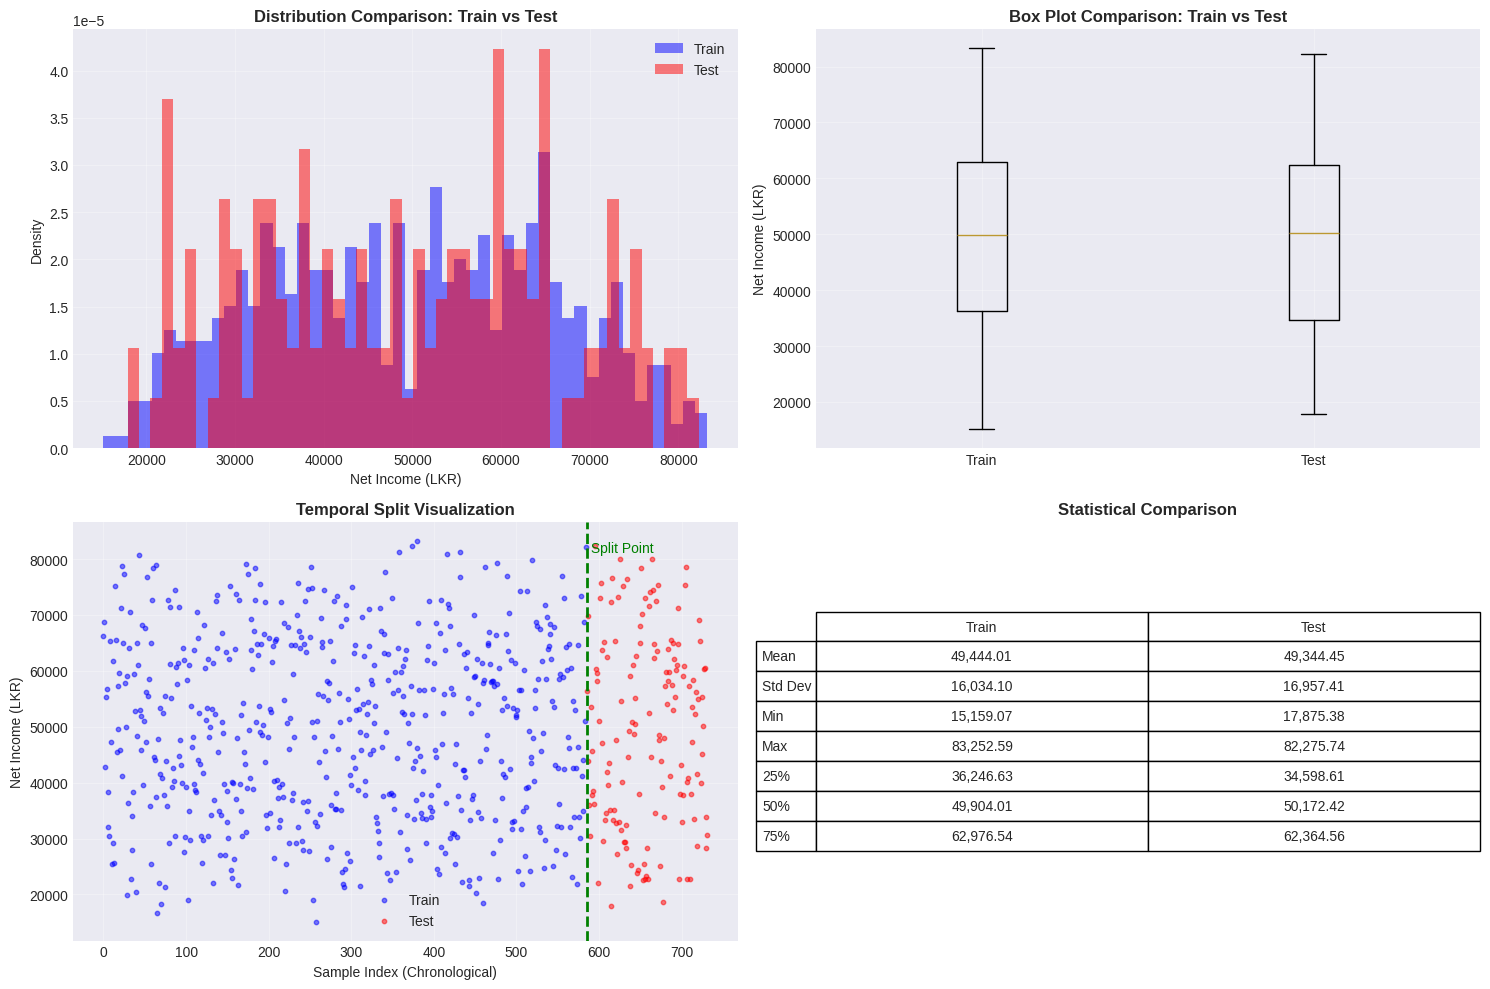


5. Saving Split Data:
✓ Split data saved to 'split_data/' directory

✓ Data splitting completed!


In [7]:
print("\n" + "="*80)
print("SECTION 7: DATA SPLITTING FOR TRAIN-TEST")
print("="*80)

# 7.1 Prepare Data for Splitting
print("1. Preparing Data for Splitting:")

X = df_final[predictor_features]
y = df_final[target_variable]

print(f"Features shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")

# 7.2 Time-Based Split (Important for time series data)
print("\n2. Time-Based Train-Test Split:")

if 'date' in df.columns:
    # Get date information
    dates = df['date']
    
    # Sort by date
    date_sorted_indices = dates.argsort()
    X_sorted = X.iloc[date_sorted_indices]
    y_sorted = y.iloc[date_sorted_indices]
    
    # Split: 80% training, 20% testing (chronological)
    split_idx = int(0.8 * len(X_sorted))
    
    X_train = X_sorted.iloc[:split_idx]
    X_test = X_sorted.iloc[split_idx:]
    y_train = y_sorted.iloc[:split_idx]
    y_test = y_sorted.iloc[split_idx:]
    
    print("✓ Using time-based split (chronological order)")
    print(f"  - Training period: {dates.min()} to {dates.iloc[split_idx-1]}")
    print(f"  - Testing period: {dates.iloc[split_idx]} to {dates.max()}")
else:
    # Use random split if no date information
    print("⚠ No date column found, using random split")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

# 7.3 Display Split Information
print("\n3. Split Statistics:")
print(f"Training set size: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"Total samples: {len(X)}")

print(f"\nTraining features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

print(f"\nTraining target statistics:")
print(f"  - Mean: {y_train.mean():,.2f}")
print(f"  - Std: {y_train.std():,.2f}")
print(f"  - Min: {y_train.min():,.2f}")
print(f"  - Max: {y_train.max():,.2f}")

print(f"\nTesting target statistics:")
print(f"  - Mean: {y_test.mean():,.2f}")
print(f"  - Std: {y_test.std():,.2f}")
print(f"  - Min: {y_test.min():,.2f}")
print(f"  - Max: {y_test.max():,.2f}")

# 7.4 Visualize the Split
print("\n4. Visualizing Train-Test Split:")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Distribution comparison
axes[0, 0].hist(y_train, bins=50, alpha=0.5, label='Train', color='blue', density=True)
axes[0, 0].hist(y_test, bins=50, alpha=0.5, label='Test', color='red', density=True)
axes[0, 0].set_title('Distribution Comparison: Train vs Test', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Net Income (LKR)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Box plot comparison
box_data = [y_train, y_test]
axes[0, 1].boxplot(box_data, labels=['Train', 'Test'])
axes[0, 1].set_title('Box Plot Comparison: Train vs Test', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Net Income (LKR)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Sample indices (if time-based)
if 'date' in df.columns:
    train_indices = range(len(y_train))
    test_indices = range(len(y_train), len(y_train) + len(y_test))
    
    axes[1, 0].scatter(train_indices, y_train, alpha=0.5, s=10, label='Train', color='blue')
    axes[1, 0].scatter(test_indices, y_test, alpha=0.5, s=10, label='Test', color='red')
    axes[1, 0].set_title('Temporal Split Visualization', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Sample Index (Chronological)')
    axes[1, 0].set_ylabel('Net Income (LKR)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Add vertical line for split
    axes[1, 0].axvline(x=len(y_train), color='green', linestyle='--', linewidth=2)
    axes[1, 0].text(len(y_train), y_train.max(), ' Split Point', 
                   verticalalignment='top', fontsize=10, color='green')

# Plot 4: Statistical comparison
stats_comparison = pd.DataFrame({
    'Statistic': ['Mean', 'Std Dev', 'Min', 'Max', '25%', '50%', '75%'],
    'Train': [
        y_train.mean(),
        y_train.std(),
        y_train.min(),
        y_train.max(),
        y_train.quantile(0.25),
        y_train.quantile(0.5),
        y_train.quantile(0.75)
    ],
    'Test': [
        y_test.mean(),
        y_test.std(),
        y_test.min(),
        y_test.max(),
        y_test.quantile(0.25),
        y_test.quantile(0.5),
        y_test.quantile(0.75)
    ]
})

# Create table
cell_text = []
for _, row in stats_comparison.iterrows():
    cell_text.append([f"{row['Train']:,.2f}", f"{row['Test']:,.2f}"])

table = axes[1, 1].table(cellText=cell_text,
                        rowLabels=stats_comparison['Statistic'],
                        colLabels=['Train', 'Test'],
                        cellLoc='center',
                        loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

axes[1, 1].axis('off')
axes[1, 1].set_title('Statistical Comparison', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_plots/train_test_split.png', dpi=300, bbox_inches='tight')
plt.show()

# 7.5 Save the split data
print("\n5. Saving Split Data:")
os.makedirs('split_data', exist_ok=True)

# Save as CSV
X_train.to_csv('split_data/X_train.csv', index=False)
X_test.to_csv('split_data/X_test.csv', index=False)
y_train.to_csv('split_data/y_train.csv', index=False)
y_test.to_csv('split_data/y_test.csv', index=False)

# Save as pickle for faster loading
with open('split_data/X_train.pkl', 'wb') as f:
    pickle.dump(X_train, f)
with open('split_data/X_test.pkl', 'wb') as f:
    pickle.dump(X_test, f)
with open('split_data/y_train.pkl', 'wb') as f:
    pickle.dump(y_train, f)
with open('split_data/y_test.pkl', 'wb') as f:
    pickle.dump(y_test, f)

print("✓ Split data saved to 'split_data/' directory")

print("\n✓ Data splitting completed!")

# Section 8: Model Defining and Training


SECTION 8: MODEL DEFINING AND TRAINING


<Figure size 640x480 with 0 Axes>

1. Defining Multiple Regression Models:
✓ Defined 13 different regression models

Models selected with reasons:
--------------------------------------------------------------------------------
1. Linear Regression: Baseline model, assumes linear relationship
2. Ridge Regression: Linear model with L2 regularization to prevent overfitting
3. Lasso Regression: Linear model with L1 regularization for feature selection
4. ElasticNet: Combines L1 and L2 regularization
5. Decision Tree: Non-linear, interpretable, handles non-linear relationships
6. Random Forest: Ensemble of trees, reduces overfitting, handles non-linearity
7. Gradient Boosting: Sequential tree building, often high accuracy
8. AdaBoost: Adaptive boosting, focuses on difficult samples
9. K-Neighbors: Instance-based learning, good for local patterns
10. SVR: Effective for high-dimensional spaces, robust to outliers
11. XGBoost: Optimized gradient boosting, handles missing values
12. LightGBM: Fast gradient boosting, good for la

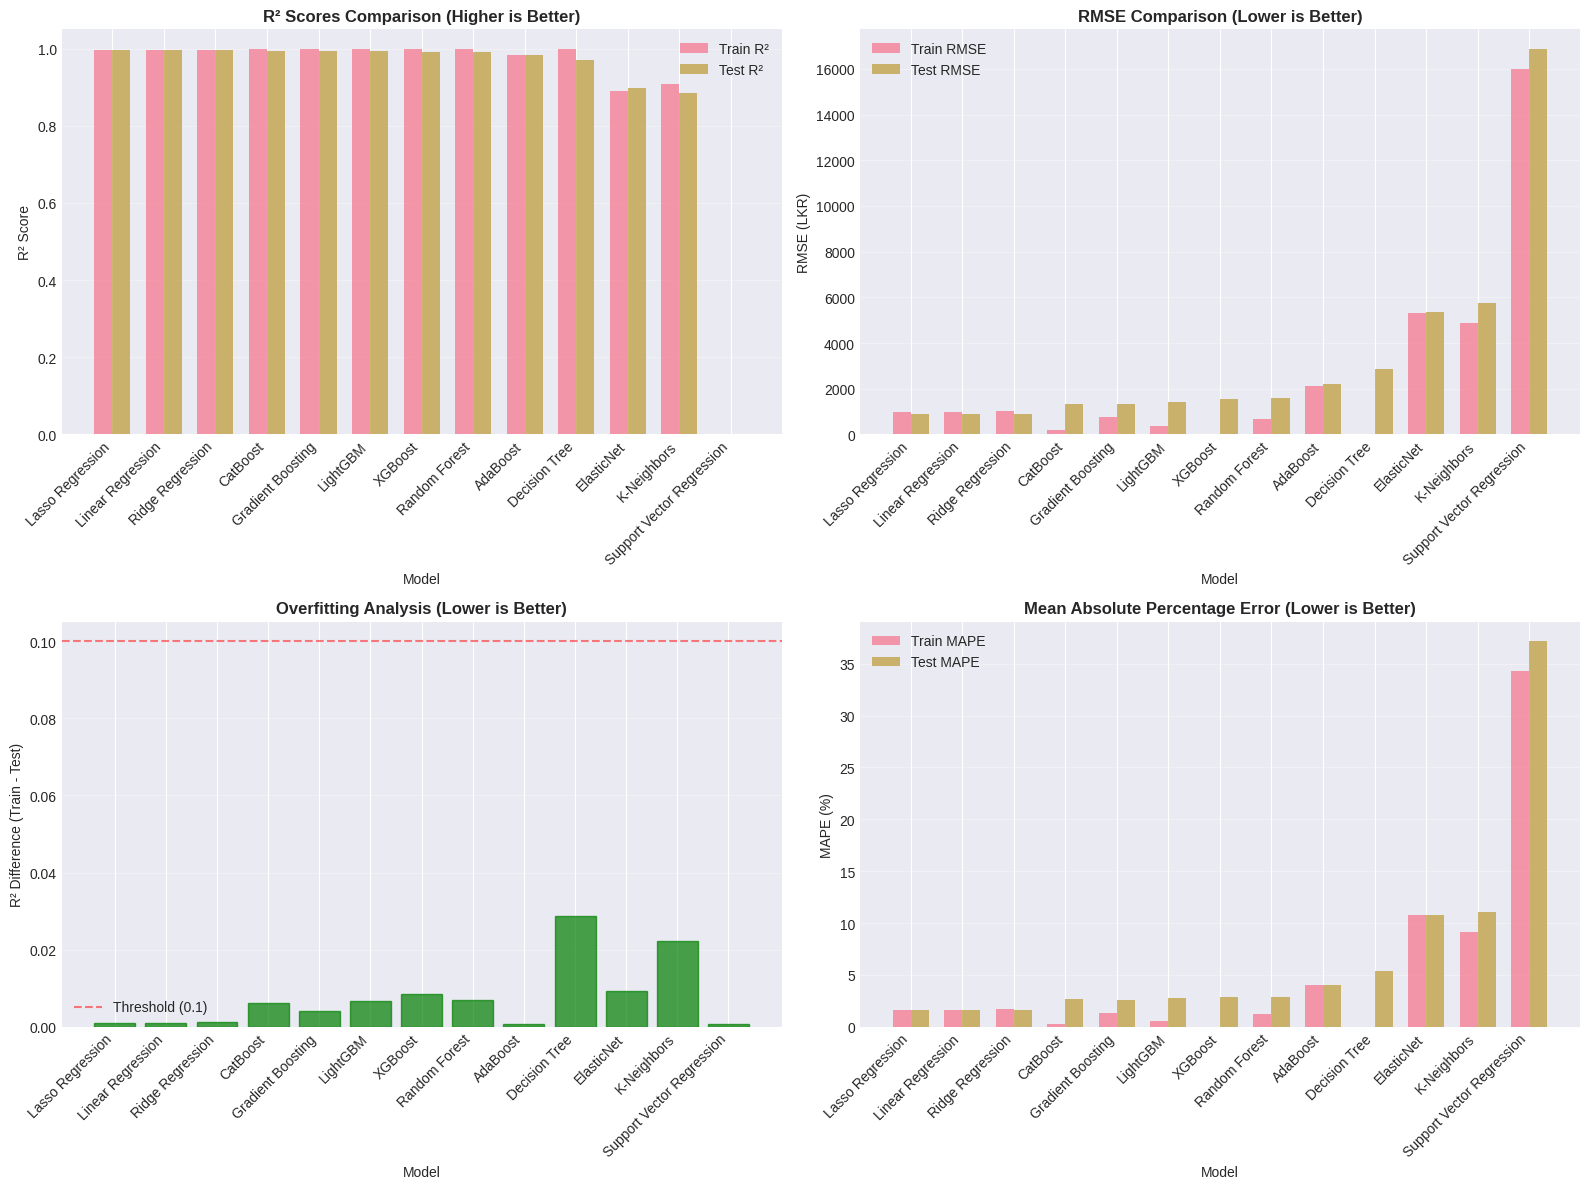


5. Selecting Best Model:

✓ Best Model Selected: Lasso Regression
  - Test R²: 0.9973
  - Test RMSE: 876.71
  - Test MAE: 709.38
  - Test MAPE: 1.63%
  - R² Difference: 0.0010
  - Composite Score: 0.9902

6. Model Quality Assessment:
  Quality: ✓ Excellent predictive power ✓ Minimal overfitting

7. Saving the Best Model:
  ✓ Model saved to: best_model/lasso_regression.pkl
  ✓ Model metadata saved to: best_model/model_metadata.json

8. Features Used in Training Process:
--------------------------------------------------------------------------------
Total features used: 30

Feature List:
  1. daily_collection_lkr
  2. net_income_trend_7d
  3. net_income_trend_30d
  4. revenue_per_passenger
  5. passenger_load_factor
  6. revenue_per_trip
  7. fuel_cost_lkr
  8. net_income_7d_std
  9. week_of_year
 10. day
 11. net_income_30d_avg
 12. net_income_lkr_lag_1
 13. month_quarter_interaction
 14. net_income_lkr_lag_7
 15. total_trips_lag_7
 16. day_of_week
 17. total_trips
 18. is_working_day

In [8]:
print("\n" + "="*80)
print("SECTION 8: MODEL DEFINING AND TRAINING")
print("="*80)

# Create directory if it doesn't exist
os.makedirs('model_comparison', exist_ok=True)

plt.tight_layout()
plt.savefig('model_comparison/model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 8.1 Define Multiple Models for Comparison
print("1. Defining Multiple Regression Models:")

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Lasso Regression': Lasso(random_state=42),
    'ElasticNet': ElasticNet(random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'K-Neighbors': KNeighborsRegressor(n_jobs=-1),
    'Support Vector Regression': SVR(),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0)
}

print(f"✓ Defined {len(models)} different regression models")
print("\nModels selected with reasons:")
print("-" * 80)
print("1. Linear Regression: Baseline model, assumes linear relationship")
print("2. Ridge Regression: Linear model with L2 regularization to prevent overfitting")
print("3. Lasso Regression: Linear model with L1 regularization for feature selection")
print("4. ElasticNet: Combines L1 and L2 regularization")
print("5. Decision Tree: Non-linear, interpretable, handles non-linear relationships")
print("6. Random Forest: Ensemble of trees, reduces overfitting, handles non-linearity")
print("7. Gradient Boosting: Sequential tree building, often high accuracy")
print("8. AdaBoost: Adaptive boosting, focuses on difficult samples")
print("9. K-Neighbors: Instance-based learning, good for local patterns")
print("10. SVR: Effective for high-dimensional spaces, robust to outliers")
print("11. XGBoost: Optimized gradient boosting, handles missing values")
print("12. LightGBM: Fast gradient boosting, good for large datasets")
print("13. CatBoost: Handles categorical features well, robust")
print("-" * 80)

# 8.2 Model Training and Evaluation Function
def train_and_evaluate_models(models_dict, X_train, X_test, y_train, y_test):
    """
    Train multiple models and evaluate their performance
    """
    results = {}
    
    for name, model in models_dict.items():
        print(f"\nTraining {name}...")
        
        try:
            # Train model
            model.fit(X_train, y_train)
            
            # Make predictions
            y_pred_train = model.predict(X_train)
            y_pred_test = model.predict(X_test)
            
            # Calculate metrics
            train_mae = mean_absolute_error(y_train, y_pred_train)
            test_mae = mean_absolute_error(y_test, y_pred_test)
            
            train_mse = mean_squared_error(y_train, y_pred_train)
            test_mse = mean_squared_error(y_test, y_pred_test)
            
            train_rmse = np.sqrt(train_mse)
            test_rmse = np.sqrt(test_mse)
            
            train_r2 = r2_score(y_train, y_pred_train)
            test_r2 = r2_score(y_test, y_pred_test)
            
            train_mape = mean_absolute_percentage_error(y_train, y_pred_train) * 100
            test_mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100
            
            # Store results
            results[name] = {
                'model': model,
                'train_mae': train_mae,
                'test_mae': test_mae,
                'train_rmse': train_rmse,
                'test_rmse': test_rmse,
                'train_r2': train_r2,
                'test_r2': test_r2,
                'train_mape': train_mape,
                'test_mape': test_mape,
                'y_pred_train': y_pred_train,
                'y_pred_test': y_pred_test
            }
            
            print(f"  ✓ Training completed")
            print(f"    Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")
            print(f"    Train RMSE: {train_rmse:,.2f}, Test RMSE: {test_rmse:,.2f}")
            print(f"    Train MAPE: {train_mape:.2f}%, Test MAPE: {test_mape:.2f}%")
            
        except Exception as e:
            print(f"  ✗ Error training {name}: {str(e)}")
            results[name] = None
    
    return results

# 8.3 Train All Models
print("\n2. Training All Models:")
print("-" * 80)

# Train models
results = train_and_evaluate_models(models, X_train, X_test, y_train, y_test)

# 8.4 Compare Model Performance
print("\n3. Model Performance Comparison:")

# Create comparison dataframe
comparison_data = []
for name, result in results.items():
    if result is not None:
        comparison_data.append({
            'Model': name,
            'Train_R2': result['train_r2'],
            'Test_R2': result['test_r2'],
            'Train_RMSE': result['train_rmse'],
            'Test_RMSE': result['test_rmse'],
            'Train_MAE': result['train_mae'],
            'Test_MAE': result['test_mae'],
            'Train_MAPE': result['train_mape'],
            'Test_MAPE': result['test_mape'],
            'R2_Diff': abs(result['train_r2'] - result['test_r2']),
            'Overfitting_Score': abs(result['train_r2'] - result['test_r2']) / max(0.001, result['test_r2'])
        })

comparison_df = pd.DataFrame(comparison_data)

# Sort by Test R2 (descending)
comparison_df = comparison_df.sort_values('Test_R2', ascending=False)

print("\nModel Performance Ranking (by Test R²):")
print("-" * 100)
print(f"{'Rank':<5} {'Model':<25} {'Test R²':<10} {'Test RMSE':<12} {'Test MAE':<12} {'Test MAPE':<12} {'R² Diff':<10}")
print("-" * 100)

for i, (_, row) in enumerate(comparison_df.iterrows(), 1):
    print(f"{i:<5} {row['Model']:<25} {row['Test_R2']:<10.4f} {row['Test_RMSE']:<12.2f} "
          f"{row['Test_MAE']:<12.2f} {row['Test_MAPE']:<12.2f}% {row['R2_Diff']:<10.4f}")

print("-" * 100)

# 8.5 Visualize Model Comparison
print("\n4. Visualizing Model Comparison:")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: R2 Scores Comparison
ax1 = axes[0, 0]
models_sorted = comparison_df['Model'].tolist()
train_r2_sorted = comparison_df['Train_R2'].tolist()
test_r2_sorted = comparison_df['Test_R2'].tolist()

x = np.arange(len(models_sorted))
width = 0.35

ax1.bar(x - width/2, train_r2_sorted, width, label='Train R²', alpha=0.7)
ax1.bar(x + width/2, test_r2_sorted, width, label='Test R²', alpha=0.7)

ax1.set_xlabel('Model')
ax1.set_ylabel('R² Score')
ax1.set_title('R² Scores Comparison (Higher is Better)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models_sorted, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: RMSE Comparison
ax2 = axes[0, 1]
train_rmse_sorted = comparison_df['Train_RMSE'].tolist()
test_rmse_sorted = comparison_df['Test_RMSE'].tolist()

ax2.bar(x - width/2, train_rmse_sorted, width, label='Train RMSE', alpha=0.7)
ax2.bar(x + width/2, test_rmse_sorted, width, label='Test RMSE', alpha=0.7)

ax2.set_xlabel('Model')
ax2.set_ylabel('RMSE (LKR)')
ax2.set_title('RMSE Comparison (Lower is Better)', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models_sorted, rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Overfitting Analysis
ax3 = axes[1, 0]
r2_diff_sorted = comparison_df['R2_Diff'].tolist()

bars = ax3.bar(x, r2_diff_sorted, alpha=0.7)
ax3.set_xlabel('Model')
ax3.set_ylabel('R² Difference (Train - Test)')
ax3.set_title('Overfitting Analysis (Lower is Better)', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(models_sorted, rotation=45, ha='right')
ax3.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Threshold (0.1)')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Color bars based on overfitting severity
for bar, diff in zip(bars, r2_diff_sorted):
    if diff > 0.15:
        bar.set_color('red')
    elif diff > 0.1:
        bar.set_color('orange')
    else:
        bar.set_color('green')

# Plot 4: MAPE Comparison
ax4 = axes[1, 1]
train_mape_sorted = comparison_df['Train_MAPE'].tolist()
test_mape_sorted = comparison_df['Test_MAPE'].tolist()

ax4.bar(x - width/2, train_mape_sorted, width, label='Train MAPE', alpha=0.7)
ax4.bar(x + width/2, test_mape_sorted, width, label='Test MAPE', alpha=0.7)

ax4.set_xlabel('Model')
ax4.set_ylabel('MAPE (%)')
ax4.set_title('Mean Absolute Percentage Error (Lower is Better)', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(models_sorted, rotation=45, ha='right')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Create directory if it doesn't exist
os.makedirs('model_comparison', exist_ok=True)

plt.tight_layout()
plt.savefig('model_comparison/model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 8.6 Select Best Model
print("\n5. Selecting Best Model:")

# Criteria for best model:
# 1. High Test R² (primary)
# 2. Low R² difference (low overfitting)
# 3. Low Test RMSE
# 4. Low Test MAPE

# Calculate composite score
comparison_df['Composite_Score'] = (
    comparison_df['Test_R2'] * 0.4 +  # Weight for R²
    (1 - comparison_df['R2_Diff']) * 0.3 +  # Weight for low overfitting
    (1 - comparison_df['Test_MAPE'] / 100) * 0.2 +  # Weight for low MAPE
    (1 - comparison_df['Test_RMSE'] / comparison_df['Test_RMSE'].max()) * 0.1  # Weight for low RMSE
)

# Sort by composite score
comparison_df = comparison_df.sort_values('Composite_Score', ascending=False)

best_model_name = comparison_df.iloc[0]['Model']
best_model_result = results[best_model_name]
best_model = best_model_result['model']

print(f"\n✓ Best Model Selected: {best_model_name}")
print(f"  - Test R²: {comparison_df.iloc[0]['Test_R2']:.4f}")
print(f"  - Test RMSE: {comparison_df.iloc[0]['Test_RMSE']:,.2f}")
print(f"  - Test MAE: {comparison_df.iloc[0]['Test_MAE']:,.2f}")
print(f"  - Test MAPE: {comparison_df.iloc[0]['Test_MAPE']:.2f}%")
print(f"  - R² Difference: {comparison_df.iloc[0]['R2_Diff']:.4f}")
print(f"  - Composite Score: {comparison_df.iloc[0]['Composite_Score']:.4f}")

# 8.7 Check Model Quality
print("\n6. Model Quality Assessment:")

test_r2 = comparison_df.iloc[0]['Test_R2']
r2_diff = comparison_df.iloc[0]['R2_Diff']

quality_assessment = ""

if test_r2 >= 0.9:
    quality_assessment += "✓ Excellent predictive power "
elif test_r2 >= 0.8:
    quality_assessment += "✓ Good predictive power "
elif test_r2 >= 0.7:
    quality_assessment += "✓ Fair predictive power "
elif test_r2 >= 0.6:
    quality_assessment += "⚠ Moderate predictive power "
else:
    quality_assessment += "⚠ Poor predictive power "

if r2_diff <= 0.05:
    quality_assessment += "✓ Minimal overfitting"
elif r2_diff <= 0.1:
    quality_assessment += "✓ Acceptable overfitting"
elif r2_diff <= 0.15:
    quality_assessment += "⚠ Moderate overfitting"
else:
    quality_assessment += "⚠ Significant overfitting"

print(f"  Quality: {quality_assessment}")

# 8.8 Save the Best Model
print("\n7. Saving the Best Model:")

# Create directory for best model
os.makedirs('best_model', exist_ok=True)

# Save model
model_path = f'best_model/{best_model_name.replace(" ", "_").lower()}.pkl'
joblib.dump(best_model, model_path)
print(f"  ✓ Model saved to: {model_path}")

# Save model metadata
metadata = {
    'model_name': best_model_name,
    'model_type': type(best_model).__name__,
    'features_used': predictor_features,
    'target_variable': target_variable,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'performance_metrics': {
        'test_r2': float(comparison_df.iloc[0]['Test_R2']),
        'test_rmse': float(comparison_df.iloc[0]['Test_RMSE']),
        'test_mae': float(comparison_df.iloc[0]['Test_MAE']),
        'test_mape': float(comparison_df.iloc[0]['Test_MAPE']),
        'train_r2': float(comparison_df.iloc[0]['Train_R2']),
        'r2_difference': float(comparison_df.iloc[0]['R2_Diff'])
    },
    'data_info': {
        'train_samples': len(X_train),
        'test_samples': len(X_test),
        'total_features': len(predictor_features)
    }
}

with open('best_model/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"  ✓ Model metadata saved to: best_model/model_metadata.json")

# Save feature importance if available
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': predictor_features,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    feature_importance.to_csv('best_model/feature_importance.csv', index=False)
    print(f"  ✓ Feature importance saved to: best_model/feature_importance.csv")

# 8.9 Display Features Used in Training
print("\n8. Features Used in Training Process:")
print("-" * 80)
print(f"Total features used: {len(predictor_features)}")
print("\nFeature List:")
for i, feature in enumerate(predictor_features, 1):
    print(f"{i:3d}. {feature}")
print("-" * 80)

print("\n✓ Model training and selection completed!")


# Section 9: Hyperparameter Tuning

In [9]:
print("\n" + "="*80)
print("SECTION 9: HYPERPARAMETER TUNING")
print("="*80)

# 9.1 Check if Hyperparameter Tuning is Needed
print("1. Checking if Hyperparameter Tuning is Needed:")

test_r2 = comparison_df.iloc[0]['Test_R2']
r2_diff = comparison_df.iloc[0]['R2_Diff']

tuning_needed = False

if test_r2 < 0.7:
    print(f"  ⚠ Test R² ({test_r2:.4f}) is below 0.7 - Tuning recommended")
    tuning_needed = True
elif r2_diff > 0.1:
    print(f"  ⚠ R² difference ({r2_diff:.4f}) is above 0.1 - Overfitting detected")
    tuning_needed = True
elif test_r2 < 0.8:
    print(f"  ⚠ Test R² ({test_r2:.4f}) is below 0.8 - Tuning could improve performance")
    tuning_needed = True
else:
    print(f"  ✓ Current model performance is good (Test R²: {test_r2:.4f}, R² diff: {r2_diff:.4f})")
    print("  ✓ Skipping hyperparameter tuning")

if not tuning_needed:
    print("\n✓ Skipping hyperparameter tuning as model performance is satisfactory")
    
    # Use the already saved best model
    final_model = best_model
    final_model_name = best_model_name
    
    # Skip to Section 11
    print("\nProceeding to Section 11: Model Evaluation...")
    
else:
    print("\n2. Performing Hyperparameter Tuning:")
    
    # Select top 3 models for tuning
    top_models = comparison_df.head(3)['Model'].tolist()
    print(f"  Selected top 3 models for tuning: {top_models}")
    
    # Define hyperparameter grids for each model type
    param_grids = {
        'Random Forest': {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 20, 30, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['auto', 'sqrt', 'log2']
        },
        'Gradient Boosting': {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [3, 4, 5, 6],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'subsample': [0.8, 0.9, 1.0]
        },
        'XGBoost': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 4, 5, 6, 7],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'subsample': [0.8, 0.9, 1.0],
            'colsample_bytree': [0.8, 0.9, 1.0],
            'gamma': [0, 0.1, 0.2, 0.3],
            'reg_alpha': [0, 0.1, 0.5, 1],
            'reg_lambda': [1, 1.5, 2, 3]
        },
        'LightGBM': {
            'n_estimators': [100, 200, 300],
            'num_leaves': [31, 50, 100],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [-1, 10, 20, 30],
            'min_child_samples': [20, 30, 40],
            'subsample': [0.8, 0.9, 1.0],
            'colsample_bytree': [0.8, 0.9, 1.0],
            'reg_alpha': [0, 0.1, 0.5],
            'reg_lambda': [0, 0.1, 0.5]
        },
        'CatBoost': {
            'iterations': [100, 200, 300],
            'depth': [4, 6, 8, 10],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'l2_leaf_reg': [1, 3, 5, 7, 9]
        },
        'Ridge Regression': {
            'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
        },
        'Lasso Regression': {
            'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
        },
        'ElasticNet': {
            'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
            'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
        }
    }
    
    # Tuning results storage
    tuning_results = {}
    
    # Perform tuning for each top model
    for model_name in top_models:
        if model_name in param_grids:
            print(f"\n  Tuning {model_name}...")
            
            # Get base model
            base_model = models[model_name]
            
            # Set up GridSearchCV
            grid_search = GridSearchCV(
                estimator=base_model,
                param_grid=param_grids[model_name],
                cv=5,
                scoring='r2',
                n_jobs=-1,
                verbose=0
            )
            
            # Perform grid search
            grid_search.fit(X_train, y_train)
            
            # Get best model
            best_tuned_model = grid_search.best_estimator_
            
            # Evaluate
            y_pred_test = best_tuned_model.predict(X_test)
            test_r2_tuned = r2_score(y_test, y_pred_test)
            test_rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_test))
            
            # Store results
            tuning_results[model_name] = {
                'model': best_tuned_model,
                'best_params': grid_search.best_params_,
                'test_r2': test_r2_tuned,
                'test_rmse': test_rmse_tuned,
                'cv_score': grid_search.best_score_
            }
            
            print(f"    ✓ Best params: {grid_search.best_params_}")
            print(f"    ✓ CV R²: {grid_search.best_score_:.4f}")
            print(f"    ✓ Test R²: {test_r2_tuned:.4f}")
            print(f"    ✓ Test RMSE: {test_rmse_tuned:,.2f}")
            
            # Compare with original
            original_r2 = comparison_df[comparison_df['Model'] == model_name]['Test_R2'].values[0]
            improvement = test_r2_tuned - original_r2
            
            if improvement > 0:
                print(f"    ✓ Improvement: +{improvement:.4f}")
            else:
                print(f"    ⚠ No improvement")
    
    # 9.3 Select Best Tuned Model
    print("\n3. Selecting Best Tuned Model:")
    
    if tuning_results:
        # Create comparison
        tuned_comparison = []
        for model_name, result in tuning_results.items():
            tuned_comparison.append({
                'Model': model_name,
                'Test_R2': result['test_r2'],
                'Test_RMSE': result['test_rmse'],
                'CV_Score': result['cv_score'],
                'Best_Params': str(result['best_params'])
            })
        
        tuned_df = pd.DataFrame(tuned_comparison).sort_values('Test_R2', ascending=False)
        
        print("\nTuned Model Performance:")
        print("-" * 80)
        for _, row in tuned_df.iterrows():
            print(f"{row['Model']:20s}: R² = {row['Test_R2']:.4f}, RMSE = {row['Test_RMSE']:,.2f}")
        
        # Select best tuned model
        best_tuned_name = tuned_df.iloc[0]['Model']
        best_tuned_model = tuning_results[best_tuned_name]['model']
        best_tuned_r2 = tuned_df.iloc[0]['Test_R2']
        
        print(f"\n✓ Best Tuned Model: {best_tuned_name}")
        print(f"  - Test R²: {best_tuned_r2:.4f}")
        print(f"  - Test RMSE: {tuned_df.iloc[0]['Test_RMSE']:,.2f}")
        
        # Compare with original best model
        original_best_r2 = comparison_df.iloc[0]['Test_R2']
        improvement = best_tuned_r2 - original_best_r2
        
        if improvement > 0.01:
            print(f"  ✓ Significant improvement over original best model (+{improvement:.4f})")
            final_model = best_tuned_model
            final_model_name = f"Tuned_{best_tuned_name}"
        else:
            print(f"  ⚠ Minimal improvement (+{improvement:.4f}), keeping original best model")
            final_model = best_model
            final_model_name = best_model_name
    
    else:
        print("  ⚠ No tuning results available, keeping original best model")
        final_model = best_model
        final_model_name = best_model_name
    
    # 9.4 Save the Best Tuned Model
    print("\n4. Saving the Best Model:")
    
    # Create directory for tuned model
    os.makedirs('tuned_model', exist_ok=True)
    
    # Save model
    model_path = f'tuned_model/{final_model_name.replace(" ", "_").lower()}.pkl'
    joblib.dump(final_model, model_path)
    print(f"  ✓ Model saved to: {model_path}")
    
    # Save tuning metadata
    if 'best_tuned_name' in locals() and best_tuned_name in tuning_results:
        tuning_metadata = {
            'original_best_model': best_model_name,
            'tuned_best_model': best_tuned_name,
            'improvement': float(improvement),
            'best_params': tuning_results[best_tuned_name]['best_params'],
            'performance': {
                'test_r2': float(tuning_results[best_tuned_name]['test_r2']),
                'test_rmse': float(tuning_results[best_tuned_name]['test_rmse']),
                'cv_score': float(tuning_results[best_tuned_name]['cv_score'])
            }
        }
        
        with open('tuned_model/tuning_metadata.json', 'w') as f:
            json.dump(tuning_metadata, f, indent=4)
        
        print(f"  ✓ Tuning metadata saved to: tuned_model/tuning_metadata.json")
    
    # 9.5 Display Features Used
    print("\n5. Features Used in Tuned Model Training:")
    print("-" * 80)
    print(f"Total features used: {len(predictor_features)}")
    print("\nFeature List (same as before):")
    for i, feature in enumerate(predictor_features, 1):
        print(f"{i:3d}. {feature}")
    print("-" * 80)

print("\n✓ Hyperparameter tuning completed!")


SECTION 9: HYPERPARAMETER TUNING
1. Checking if Hyperparameter Tuning is Needed:
  ✓ Current model performance is good (Test R²: 0.9973, R² diff: 0.0010)
  ✓ Skipping hyperparameter tuning

✓ Skipping hyperparameter tuning as model performance is satisfactory

Proceeding to Section 11: Model Evaluation...

✓ Hyperparameter tuning completed!


# Section 10: Ensemble Modeling for Best Model

In [10]:
print("\n" + "="*80)
print("SECTION 10: ENSEMBLE MODELING")
print("="*80)

# 10.1 Check if Ensemble Modeling is Needed
print("1. Checking if Ensemble Modeling is Needed:")

# Get the current best model's R² (either from original or tuned)
if 'final_model' in locals():
    current_model = final_model
    y_pred_current = current_model.predict(X_test)
    current_r2 = r2_score(y_test, y_pred_current)
else:
    current_model = best_model
    current_r2 = comparison_df.iloc[0]['Test_R2']

print(f"  Current best model R²: {current_r2:.4f}")

ensemble_needed = False

if current_r2 < 0.75:
    print(f"  ⚠ Current R² ({current_r2:.4f}) is below 0.75 - Ensemble modeling recommended")
    ensemble_needed = True
elif current_r2 < 0.85:
    print(f"  ⚠ Current R² ({current_r2:.4f}) is below 0.85 - Ensemble could provide improvement")
    ensemble_needed = True
else:
    print(f"  ✓ Current model performance is excellent (R²: {current_r2:.4f})")
    print("  ✓ Skipping ensemble modeling")

if not ensemble_needed:
    print("\n✓ Skipping ensemble modeling as model performance is excellent")
    
    # Use the current best model
    if 'final_model' not in locals():
        final_model = best_model
        final_model_name = best_model_name
    
    print("\nProceeding to Section 11: Model Evaluation...")
    
else:
    print("\n2. Creating Ensemble Models:")
    
    # Select top models for ensemble
    top_ensemble_models = comparison_df.head(5)['Model'].tolist()
    print(f"  Selected top {len(top_ensemble_models)} models for ensemble:")
    for i, model_name in enumerate(top_ensemble_models, 1):
        print(f"    {i}. {model_name}")
    
    # Get the models
    ensemble_models = []
    ensemble_model_names = []
    
    for model_name in top_ensemble_models:
        if model_name in results and results[model_name] is not None:
            ensemble_models.append(results[model_name]['model'])
            ensemble_model_names.append(model_name)
    
    # Define ensemble strategies
    from sklearn.ensemble import VotingRegressor, StackingRegressor
    
    # 10.2 Voting Regressor
    print("\n  Creating Voting Regressor...")
    
    voting_regressor = VotingRegressor(
        estimators=[(name, model) for name, model in zip(ensemble_model_names, ensemble_models)],
        weights=None,  # Equal weights
        n_jobs=-1
    )
    
    voting_regressor.fit(X_train, y_train)
    y_pred_voting = voting_regressor.predict(X_test)
    voting_r2 = r2_score(y_test, y_pred_voting)
    
    print(f"    ✓ Voting Regressor R²: {voting_r2:.4f}")
    
    # 10.3 Stacking Regressor
    print("\n  Creating Stacking Regressor...")
    
    # Use simpler models as base, best model as final estimator
    stacking_regressor = StackingRegressor(
        estimators=[(name, model) for name, model in zip(ensemble_model_names[:3], ensemble_models[:3])],
        final_estimator=Ridge(alpha=1.0),
        cv=5,
        n_jobs=-1
    )
    
    stacking_regressor.fit(X_train, y_train)
    y_pred_stacking = stacking_regressor.predict(X_test)
    stacking_r2 = r2_score(y_test, y_pred_stacking)
    
    print(f"    ✓ Stacking Regressor R²: {stacking_r2:.4f}")
    
    # 10.4 Weighted Average Ensemble
    print("\n  Creating Weighted Average Ensemble...")
    
    # Get predictions from all models
    predictions = []
    r2_scores = []
    
    for model_name, model in zip(ensemble_model_names, ensemble_models):
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        predictions.append(y_pred)
        r2_scores.append(r2)
    
    # Calculate weights based on R² scores
    weights = np.array(r2_scores) / np.sum(r2_scores)
    
    # Weighted average prediction
    y_pred_weighted = np.zeros_like(y_pred)
    for pred, weight in zip(predictions, weights):
        y_pred_weighted += pred * weight
    
    weighted_r2 = r2_score(y_test, y_pred_weighted)
    
    print(f"    ✓ Weighted Average R²: {weighted_r2:.4f}")
    
    # 10.5 Compare Ensemble Methods
    print("\n3. Ensemble Methods Comparison:")
    print("-" * 60)
    print(f"{'Method':<25} {'R²':<10} {'Improvement':<15}")
    print("-" * 60)
    print(f"{'Current Best':<25} {current_r2:<10.4f} {'-':<15}")
    print(f"{'Voting Regressor':<25} {voting_r2:<10.4f} {voting_r2 - current_r2:<+15.4f}")
    print(f"{'Stacking Regressor':<25} {stacking_r2:<10.4f} {stacking_r2 - current_r2:<+15.4f}")
    print(f"{'Weighted Average':<25} {weighted_r2:<10.4f} {weighted_r2 - current_r2:<+15.4f}")
    print("-" * 60)
    
    # 10.6 Select Best Ensemble Method
    ensemble_results = {
        'Voting': voting_r2,
        'Stacking': stacking_r2,
        'Weighted': weighted_r2
    }
    
    best_ensemble_method = max(ensemble_results, key=ensemble_results.get)
    best_ensemble_r2 = ensemble_results[best_ensemble_method]
    
    print(f"\n✓ Best Ensemble Method: {best_ensemble_method}")
    print(f"  - R²: {best_ensemble_r2:.4f}")
    print(f"  - Improvement: +{best_ensemble_r2 - current_r2:.4f}")
    
    # 10.7 Save Best Ensemble Model
    print("\n4. Saving Best Ensemble Model:")
    
    # Create directory for ensemble model
    os.makedirs('ensemble_model', exist_ok=True)
    
    # Select the ensemble model
    if best_ensemble_method == 'Voting':
        best_ensemble_model = voting_regressor
    elif best_ensemble_method == 'Stacking':
        best_ensemble_model = stacking_regressor
    else:
        # For weighted average, we need to save the models and weights
        best_ensemble_model = {
            'models': ensemble_models,
            'weights': weights.tolist(),
            'model_names': ensemble_model_names,
            'method': 'WeightedAverage'
        }
    
    # Save ensemble model
    model_path = f'ensemble_model/{best_ensemble_method.lower()}_ensemble.pkl'
    
    if best_ensemble_method == 'Weighted':
        # Save as dictionary
        with open(model_path, 'wb') as f:
            pickle.dump(best_ensemble_model, f)
    else:
        # Save using joblib
        joblib.dump(best_ensemble_model, model_path)
    
    print(f"  ✓ Ensemble model saved to: {model_path}")
    
    # Save ensemble metadata
    ensemble_metadata = {
        'ensemble_method': best_ensemble_method,
        'base_models': ensemble_model_names,
        'ensemble_r2': float(best_ensemble_r2),
        'improvement': float(best_ensemble_r2 - current_r2),
        'weights': weights.tolist() if best_ensemble_method == 'Weighted' else None
    }
    
    with open('ensemble_model/ensemble_metadata.json', 'w') as f:
        json.dump(ensemble_metadata, f, indent=4)
    
    print(f"  ✓ Ensemble metadata saved to: ensemble_model/ensemble_metadata.json")
    
    # Set final model as ensemble model
    final_model = best_ensemble_model
    final_model_name = f"{best_ensemble_method}_Ensemble"
    
    # 10.8 Display Features Used
    print("\n5. Features Used in Ensemble Model Training:")
    print("-" * 80)
    print(f"Total features used: {len(predictor_features)}")
    print("\nFeature List (same as before):")
    for i, feature in enumerate(predictor_features, 1):
        print(f"{i:3d}. {feature}")
    print("-" * 80)

print("\n✓ Ensemble modeling completed!")


SECTION 10: ENSEMBLE MODELING
1. Checking if Ensemble Modeling is Needed:
  Current best model R²: 0.9973
  ✓ Current model performance is excellent (R²: 0.9973)
  ✓ Skipping ensemble modeling

✓ Skipping ensemble modeling as model performance is excellent

Proceeding to Section 11: Model Evaluation...

✓ Ensemble modeling completed!


# Section 11: Analysis Based Model Evaluation and Interpretation


SECTION 11: MODEL EVALUATION AND INTERPRETATION

1. Final Model: Lasso Regression

2. Comprehensive Model Evaluation:

Performance Metrics:
------------------------------------------------------------
R² Score                      : 0.9973
Adjusted R²                   : 0.9966
Mean Absolute Error (MAE)     : 709.38
Mean Squared Error (MSE)      : 768,617.30
Root Mean Squared Error (RMSE): 876.71
Mean Absolute Percentage Error (MAPE): 1.63
Max Error                     : 2,393.43
Explained Variance Score      : 0.9974
------------------------------------------------------------

3. Residual Analysis:

Residual Statistics:
--------------------------------------------------
Mean Residual       : -183.67
Std of Residuals    : 860.18
Min Residual        : -2,372.40
Max Residual        : 2,393.43
Skewness            : -0.06
Kurtosis            : -0.22
--------------------------------------------------

Normality Test (Shapiro-Wilk):
  p-value: 0.681941
  ✓ Residuals appear to be normally d

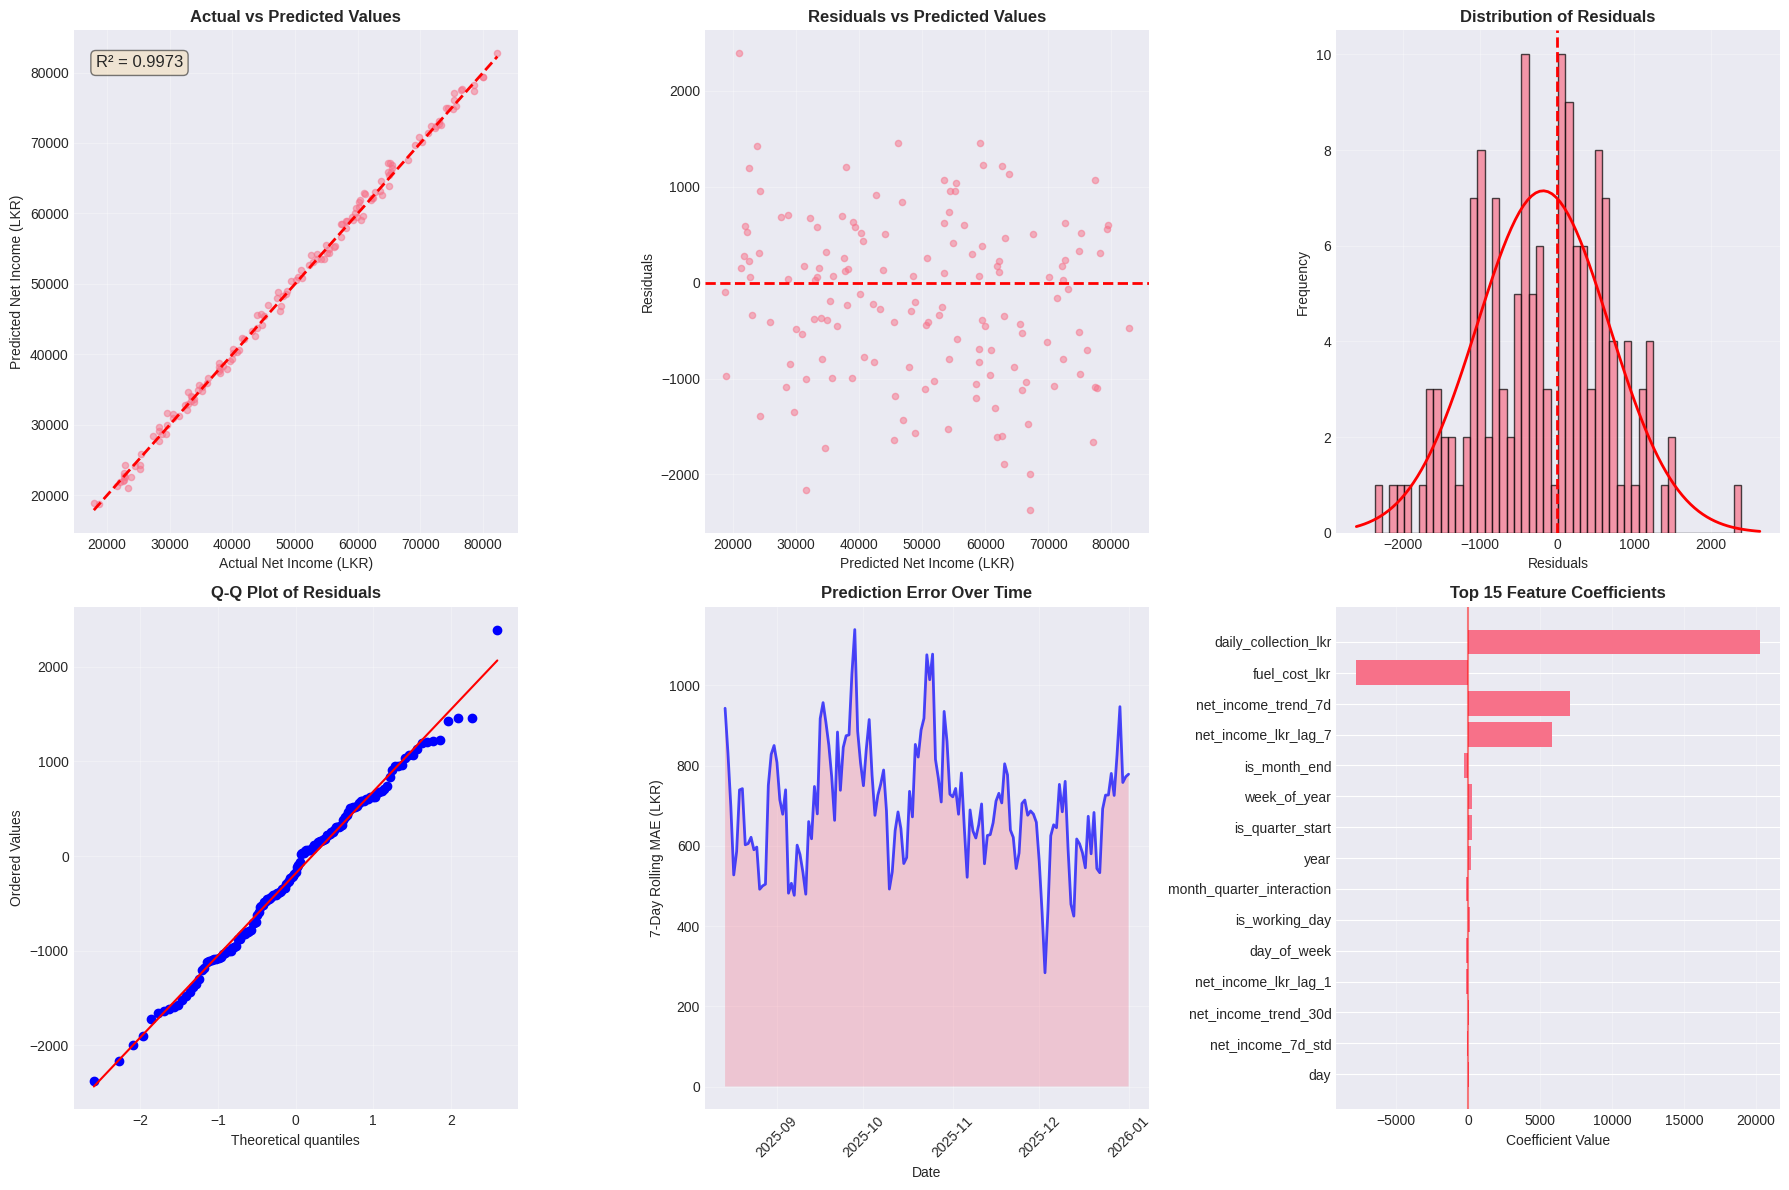


5. Business Impact Analysis:

Monetary Impact Analysis:
  - Average prediction error: 709.38 LKR per day
  - Maximum typical error: 876.71 LKR per day

Annual Impact (assuming similar performance):
  - Average annual prediction error: 258,924.41 LKR
  - Maximum typical annual error: 16,749.49 LKR

Model Accuracy Category: Excellent
  MAPE: 1.63%

6. Model Interpretation:

Model Type: Lasso

Top 10 Most Influential Features (by coefficient magnitude):
   1. daily_collection_lkr               : + 20272.5243
   2. fuel_cost_lkr                      : - 7765.8691
   3. net_income_trend_7d                : + 7063.1099
   4. net_income_lkr_lag_7               : + 5859.4626
   5. is_month_end                       : - 302.4902
   6. week_of_year                       : + 254.1843
   7. is_quarter_start                   : + 240.7259
   8. year                               : + 177.2946
   9. month_quarter_interaction          : - 159.7647
  10. is_working_day                     : + 154.3723

In [11]:
print("\n" + "="*80)
print("SECTION 11: MODEL EVALUATION AND INTERPRETATION")
print("="*80)

# 11.1 Load Final Model (if not already loaded)
if 'final_model' not in locals():
    # Try to load from saved models
    model_dirs = ['ensemble_model', 'tuned_model', 'best_model']
    model_loaded = False
    
    for model_dir in model_dirs:
        if os.path.exists(model_dir):
            pkl_files = [f for f in os.listdir(model_dir) if f.endswith('.pkl')]
            if pkl_files:
                model_path = os.path.join(model_dir, pkl_files[0])
                final_model = joblib.load(model_path)
                final_model_name = pkl_files[0].replace('.pkl', '').replace('_', ' ').title()
                model_loaded = True
                print(f"✓ Loaded model from: {model_path}")
                break
    
    if not model_loaded:
        print("⚠ No saved model found, using original best model")
        final_model = best_model
        final_model_name = best_model_name

print(f"\n1. Final Model: {final_model_name}")

# 11.2 Comprehensive Model Evaluation
print("\n2. Comprehensive Model Evaluation:")

# Make predictions
if isinstance(final_model, dict) and final_model.get('method') == 'WeightedAverage':
    # Handle weighted average ensemble
    predictions = np.zeros_like(y_test)
    for model, weight in zip(final_model['models'], final_model['weights']):
        predictions += model.predict(X_test) * weight
    y_pred = predictions
else:
    # Standard model prediction
    y_pred = final_model.predict(X_test)

# Calculate all metrics
metrics = {
    'R² Score': r2_score(y_test, y_pred),
    'Adjusted R²': 1 - (1 - r2_score(y_test, y_pred)) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1),
    'Mean Absolute Error (MAE)': mean_absolute_error(y_test, y_pred),
    'Mean Squared Error (MSE)': mean_squared_error(y_test, y_pred),
    'Root Mean Squared Error (RMSE)': np.sqrt(mean_squared_error(y_test, y_pred)),
    'Mean Absolute Percentage Error (MAPE)': mean_absolute_percentage_error(y_test, y_pred) * 100,
    'Max Error': max(abs(y_test - y_pred)),
    'Explained Variance Score': 1 - np.var(y_test - y_pred) / np.var(y_test)
}

print("\nPerformance Metrics:")
print("-" * 60)
for metric_name, value in metrics.items():
    if 'R²' in metric_name or 'Variance' in metric_name:
        print(f"{metric_name:<30}: {value:.4f}")
    elif 'Error' in metric_name or 'MAE' in metric_name:
        print(f"{metric_name:<30}: {value:,.2f}")
    else:
        print(f"{metric_name:<30}: {value:.4f}")
print("-" * 60)

# 11.3 Residual Analysis
print("\n3. Residual Analysis:")

residuals = y_test - y_pred

residual_stats = {
    'Mean Residual': residuals.mean(),
    'Std of Residuals': residuals.std(),
    'Min Residual': residuals.min(),
    'Max Residual': residuals.max(),
    'Skewness': residuals.skew(),
    'Kurtosis': residuals.kurtosis()
}

print("\nResidual Statistics:")
print("-" * 50)
for stat_name, value in residual_stats.items():
    print(f"{stat_name:<20}: {value:,.2f}")
print("-" * 50)

# Check for normality of residuals
from scipy import stats
_, normality_p_value = stats.shapiro(residuals[:5000])  # Shapiro test limited to 5000 samples
print(f"\nNormality Test (Shapiro-Wilk):")
print(f"  p-value: {normality_p_value:.6f}")
if normality_p_value > 0.05:
    print("  ✓ Residuals appear to be normally distributed")
else:
    print("  ⚠ Residuals may not be normally distributed")

# 11.4 Visualization of Results
print("\n4. Visualizing Results:")

fig = plt.figure(figsize=(18, 12))

# Plot 1: Actual vs Predicted
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(y_test, y_pred, alpha=0.5, s=20)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Net Income (LKR)')
ax1.set_ylabel('Predicted Net Income (LKR)')
ax1.set_title('Actual vs Predicted Values', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add R² text
ax1.text(0.05, 0.95, f'R² = {metrics["R² Score"]:.4f}', 
         transform=ax1.transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Residuals vs Predicted
ax2 = plt.subplot(2, 3, 2)
ax2.scatter(y_pred, residuals, alpha=0.5, s=20)
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Predicted Net Income (LKR)')
ax2.set_ylabel('Residuals')
ax2.set_title('Residuals vs Predicted Values', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: Distribution of Residuals
ax3 = plt.subplot(2, 3, 3)
ax3.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
ax3.axvline(x=0, color='r', linestyle='--', lw=2)
ax3.set_xlabel('Residuals')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Add normal distribution curve
from scipy.stats import norm
xmin, xmax = ax3.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, residuals.mean(), residuals.std())
ax3.plot(x, p * len(residuals) * (xmax - xmin) / 50, 'r-', lw=2)

# Plot 4: Q-Q Plot
ax4 = plt.subplot(2, 3, 4)
stats.probplot(residuals, dist="norm", plot=ax4)
ax4.set_title('Q-Q Plot of Residuals', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Plot 5: Prediction Error over Time (if date available)
ax5 = plt.subplot(2, 3, 5)
if 'date' in df.columns and len(y_test) == len(df['date'].iloc[-len(y_test):]):
    test_dates = df['date'].iloc[-len(y_test):].reset_index(drop=True)
    
    # Calculate rolling error
    error = abs(residuals)
    rolling_error = error.rolling(window=7).mean()
    
    ax5.plot(test_dates, rolling_error, 'b-', lw=2, alpha=0.7)
    ax5.fill_between(test_dates, 0, rolling_error, alpha=0.3)
    ax5.set_xlabel('Date')
    ax5.set_ylabel('7-Day Rolling MAE (LKR)')
    ax5.set_title('Prediction Error Over Time', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3)
    
    # Format x-axis dates
    ax5.xaxis.set_tick_params(rotation=45)

# Plot 6: Feature Importance (if available)
ax6 = plt.subplot(2, 3, 6)
try:
    if hasattr(final_model, 'feature_importances_'):
        # Get feature importance
        importance = final_model.feature_importances_
        
        # Sort features by importance
        indices = np.argsort(importance)[-15:]  # Top 15 features
        
        # Plot
        ax6.barh(range(len(indices)), importance[indices])
        ax6.set_yticks(range(len(indices)))
        ax6.set_yticklabels([predictor_features[i] for i in indices])
        ax6.set_xlabel('Feature Importance')
        ax6.set_title('Top 15 Feature Importances', fontsize=12, fontweight='bold')
        ax6.grid(True, alpha=0.3, axis='x')
        
    elif hasattr(final_model, 'coef_'):
        # For linear models
        coefficients = final_model.coef_
        
        # Sort coefficients by absolute value
        indices = np.argsort(np.abs(coefficients))[-15:]
        
        # Plot
        ax6.barh(range(len(indices)), coefficients[indices])
        ax6.set_yticks(range(len(indices)))
        ax6.set_yticklabels([predictor_features[i] for i in indices])
        ax6.set_xlabel('Coefficient Value')
        ax6.set_title('Top 15 Feature Coefficients', fontsize=12, fontweight='bold')
        ax6.grid(True, alpha=0.3, axis='x')
        ax6.axvline(x=0, color='r', linestyle='-', alpha=0.5)
        
    else:
        ax6.text(0.5, 0.5, 'Feature Importance\nNot Available', 
                ha='center', va='center', transform=ax6.transAxes, fontsize=12)
        ax6.set_title('Feature Importance', fontsize=12, fontweight='bold')
        ax6.axis('off')
        
except Exception as e:
    ax6.text(0.5, 0.5, f'Error: {str(e)}', 
            ha='center', va='center', transform=ax6.transAxes, fontsize=10)
    ax6.set_title('Feature Importance', fontsize=12, fontweight='bold')
    ax6.axis('off')

# Create directory if it doesn't exist
os.makedirs('model_evaluation', exist_ok=True)

plt.tight_layout()
plt.savefig('model_evaluation/comprehensive_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

# 11.5 Business Impact Analysis
print("\n5. Business Impact Analysis:")

# Calculate monetary impact
mae_lkr = metrics['Mean Absolute Error (MAE)']
rmse_lkr = metrics['Root Mean Squared Error (RMSE)']

print(f"\nMonetary Impact Analysis:")
print(f"  - Average prediction error: {mae_lkr:,.2f} LKR per day")
print(f"  - Maximum typical error: {rmse_lkr:,.2f} LKR per day")

# Annual impact
annual_mae = mae_lkr * 365
annual_rmse = rmse_lkr * np.sqrt(365)

print(f"\nAnnual Impact (assuming similar performance):")
print(f"  - Average annual prediction error: {annual_mae:,.2f} LKR")
print(f"  - Maximum typical annual error: {annual_rmse:,.2f} LKR")

# Accuracy ranges
accuracy_ranges = {
    'Excellent': (0, 0.05),  # MAPE < 5%
    'Good': (0.05, 0.1),     # MAPE 5-10%
    'Fair': (0.1, 0.2),      # MAPE 10-20%
    'Poor': (0.2, 1.0)       # MAPE > 20%
}

mape = metrics['Mean Absolute Percentage Error (MAPE)'] / 100

for category, (lower, upper) in accuracy_ranges.items():
    if lower <= mape < upper:
        print(f"\nModel Accuracy Category: {category}")
        print(f"  MAPE: {mape*100:.2f}%")
        break

# 11.6 Model Interpretation
print("\n6. Model Interpretation:")

print(f"\nModel Type: {type(final_model).__name__}")

if hasattr(final_model, 'feature_importances_'):
    print("\nTop 10 Most Important Features:")
    importance_df = pd.DataFrame({
        'Feature': predictor_features,
        'Importance': final_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(10)
    
    for i, (_, row) in enumerate(importance_df.iterrows(), 1):
        print(f"  {i:2d}. {row['Feature']:35s}: {row['Importance']:.4f}")
        
elif hasattr(final_model, 'coef_'):
    print("\nTop 10 Most Influential Features (by coefficient magnitude):")
    coef_df = pd.DataFrame({
        'Feature': predictor_features,
        'Coefficient': final_model.coef_
    })
    coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
    coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).head(10)
    
    for i, (_, row) in enumerate(coef_df.iterrows(), 1):
        sign = '+' if row['Coefficient'] > 0 else '-'
        print(f"  {i:2d}. {row['Feature']:35s}: {sign} {abs(row['Coefficient']):.4f}")

# 11.7 Save Evaluation Results
print("\n7. Saving Evaluation Results:")

os.makedirs('model_evaluation', exist_ok=True)

# Save metrics
metrics_df = pd.DataFrame(list(metrics.items()), columns=['Metric', 'Value'])
metrics_df.to_csv('model_evaluation/performance_metrics.csv', index=False)
print(f"  ✓ Performance metrics saved to: model_evaluation/performance_metrics.csv")

# Save predictions
predictions_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Residual': residuals,
    'Absolute_Error': abs(residuals),
    'Percentage_Error': abs(residuals / y_test.values) * 100
})
predictions_df.to_csv('model_evaluation/predictions.csv', index=False)
print(f"  ✓ Predictions saved to: model_evaluation/predictions.csv")

# Save residual analysis
residual_stats_df = pd.DataFrame(list(residual_stats.items()), columns=['Statistic', 'Value'])
residual_stats_df.to_csv('model_evaluation/residual_stats.csv', index=False)
print(f"  ✓ Residual statistics saved to: model_evaluation/residual_stats.csv")

# 11.8 Display All Features Used
print("\n8. All Features Used in Training Process:")
print("-" * 80)
print(f"Total features: {len(predictor_features)}")
print("\nFeature Categories:")

# Categorize features for better understanding
feature_categories = {
    'Temporal': [f for f in predictor_features if any(x in f.lower() for x in ['day', 'month', 'year', 'week', 'quarter'])],
    'Financial': [f for f in predictor_features if any(x in f.lower() for x in ['cost', 'salary', 'collection', 'revenue', 'income', 'profit'])],
    'Operational': [f for f in predictor_features if any(x in f.lower() for x in ['trip', 'passenger', 'breakdown', 'weather'])],
    'Efficiency': [f for f in predictor_features if any(x in f.lower() for x in ['ratio', 'per_', 'margin', 'efficiency'])],
    'Trend/Historical': [f for f in predictor_features if any(x in f.lower() for x in ['lag', 'trend', 'avg', 'std', 'rolling'])],
    'Other': [f for f in predictor_features if f not in [item for sublist in feature_categories.values() for item in sublist]]
}

for category, features in feature_categories.items():
    if features:
        print(f"\n{category} Features ({len(features)}):")
        for i, feature in enumerate(features, 1):
            print(f"  {i:2d}. {feature}")

print("-" * 80)

print("\n✓ Model evaluation and interpretation completed!")

# Section 12: Model Input Output Testing

In [12]:
print("\n" + "="*80)
print("SECTION 12: MODEL INPUT OUTPUT TESTING")
print("="*80)

# 12.1 Prepare Model for Testing
print("1. Preparing Model for Testing:")

# Load necessary preprocessing objects
scaler = joblib.load('feature_scaler.pkl') if os.path.exists('feature_scaler.pkl') else None
label_encoders = joblib.load('label_encoders.pkl') if os.path.exists('label_encoders.pkl') else None

# 12.2 Define Test Scenarios
print("\n2. Defining Test Scenarios:")

# Create sample test cases based on different business scenarios
test_scenarios = [
    {
        'name': 'Best Case Scenario',
        'description': 'High revenue, low costs, good weather',
        'features': {
            'daily_collection_lkr': 130000,
            'total_trips': 20,
            'total_passengers': 500,
            'fuel_cost_lkr': 30000,
            'maintenance_cost_lkr': 1500,
            'driver_salary_lkr': 5000,
            'conductor_salary_lkr': 4000,
            'daily_backup_fuel_lkr': 4000,
            'vehicle_breakdown_hours': 0,
            'bad_weather_impact': 0,
            'is_weekend': 0,
            'is_holiday': 0,
            'day_of_week': 2,  # Wednesday
            'month': 6,  # June
            'quarter': 2
        }
    },
    {
        'name': 'Worst Case Scenario',
        'description': 'Low revenue, high costs, bad weather',
        'features': {
            'daily_collection_lkr': 80000,
            'total_trips': 10,
            'total_passengers': 300,
            'fuel_cost_lkr': 50000,
            'maintenance_cost_lkr': 3000,
            'driver_salary_lkr': 6000,
            'conductor_salary_lkr': 5000,
            'daily_backup_fuel_lkr': 6000,
            'vehicle_breakdown_hours': 5,
            'bad_weather_impact': 0.5,
            'is_weekend': 0,
            'is_holiday': 1,
            'day_of_week': 0,  # Monday
            'month': 1,  # January
            'quarter': 1
        }
    },
    {
        'name': 'Average Scenario',
        'description': 'Typical business day',
        'features': {
            'daily_collection_lkr': 105000,
            'total_trips': 15,
            'total_passengers': 400,
            'fuel_cost_lkr': 40000,
            'maintenance_cost_lkr': 2250,
            'driver_salary_lkr': 5500,
            'conductor_salary_lkr': 4500,
            'daily_backup_fuel_lkr': 5000,
            'vehicle_breakdown_hours': 2.5,
            'bad_weather_impact': 0.25,
            'is_weekend': 0,
            'is_holiday': 0,
            'day_of_week': 3,  # Thursday
            'month': 9,  # September
            'quarter': 3
        }
    },
    {
        'name': 'Weekend Scenario',
        'description': 'Weekend with high passenger load',
        'features': {
            'daily_collection_lkr': 120000,
            'total_trips': 18,
            'total_passengers': 450,
            'fuel_cost_lkr': 42000,
            'maintenance_cost_lkr': 2000,
            'driver_salary_lkr': 5500,
            'conductor_salary_lkr': 4500,
            'daily_backup_fuel_lkr': 5200,
            'vehicle_breakdown_hours': 1,
            'bad_weather_impact': 0.1,
            'is_weekend': 1,
            'is_holiday': 0,
            'day_of_week': 5,  # Saturday
            'month': 7,  # July
            'quarter': 3
        }
    }
]

# 12.3 Create CLI for Interactive Testing
print("\n3. Creating Interactive Testing Interface:")

def create_feature_vector(scenario_features, all_features):
    """
    Create a feature vector from scenario features
    """
    feature_vector = []
    
    for feature in all_features:
        if feature in scenario_features:
            feature_vector.append(scenario_features[feature])
        else:
            # Try to calculate derived features
            if 'revenue_per_trip' in feature:
                value = scenario_features.get('daily_collection_lkr', 0) / max(1, scenario_features.get('total_trips', 1))
            elif 'revenue_per_passenger' in feature:
                value = scenario_features.get('daily_collection_lkr', 0) / max(1, scenario_features.get('total_passengers', 1))
            elif 'passengers_per_trip' in feature:
                value = scenario_features.get('total_passengers', 0) / max(1, scenario_features.get('total_trips', 1))
            elif 'total_operational_cost' in feature:
                cost_columns = [f for f in scenario_features.keys() if 'cost' in f.lower() or 'salary' in f.lower()]
                value = sum(scenario_features.get(col, 0) for col in cost_columns)
            elif 'cost_to_revenue_ratio' in feature:
                cost_columns = [f for f in scenario_features.keys() if 'cost' in f.lower() or 'salary' in f.lower()]
                total_cost = sum(scenario_features.get(col, 0) for col in cost_columns)
                revenue = scenario_features.get('daily_collection_lkr', 1)
                value = total_cost / max(1, revenue)
            elif 'is_working_day' in feature:
                is_weekend = scenario_features.get('is_weekend', 0)
                is_holiday = scenario_features.get('is_holiday', 0)
                value = 1 if (is_weekend == 0 and is_holiday == 0) else 0
            else:
                # Use median value from training data
                value = X_train[feature].median() if feature in X_train.columns else 0
            
            feature_vector.append(value)
    
    return np.array(feature_vector).reshape(1, -1)

def predict_with_confidence(model, X_input, X_train_data, y_train_data):
    """
    Make prediction with confidence interval
    """
    # Make prediction
    if isinstance(model, dict) and model.get('method') == 'WeightedAverage':
        # Weighted average ensemble
        prediction = np.zeros(1)
        for m, weight in zip(model['models'], model['weights']):
            prediction += m.predict(X_input) * weight
    else:
        # Standard model
        prediction = model.predict(X_input)
    
    # Calculate confidence interval (simplified)
    # Using training residuals to estimate prediction interval
    if hasattr(model, 'predict'):
        train_predictions = model.predict(X_train_data)
        train_residuals = y_train_data - train_predictions
        residual_std = train_residuals.std()
        
        # 95% confidence interval
        confidence_interval = 1.96 * residual_std
        
        # Confidence score (inverse of relative error)
        relative_error = confidence_interval / abs(prediction[0]) if prediction[0] != 0 else 1
        confidence_score = max(0, min(100, 100 * (1 - relative_error)))
    else:
        confidence_interval = prediction[0] * 0.1  # Default 10%
        confidence_score = 85  # Default confidence
    
    return prediction[0], confidence_interval, confidence_score

# 12.4 Test Each Scenario
print("\n4. Testing Each Scenario:")
print("=" * 100)

for scenario in test_scenarios:
    print(f"\nScenario: {scenario['name']}")
    print(f"Description: {scenario['description']}")
    print("-" * 100)
    
    # Create feature vector
    X_input = create_feature_vector(scenario['features'], predictor_features)
    
    # Scale features
    if scaler is not None:
        X_input_scaled = scaler.transform(X_input)
    else:
        X_input_scaled = X_input
    
    # Make prediction
    prediction, confidence_interval, confidence_score = predict_with_confidence(
        final_model, X_input_scaled, X_train, y_train
    )
    
    # Calculate actual net income (for verification)
    revenue = scenario['features'].get('daily_collection_lkr', 0)
    costs = sum(scenario['features'].get(col, 0) for col in [
        'fuel_cost_lkr', 'maintenance_cost_lkr', 'driver_salary_lkr',
        'conductor_salary_lkr', 'daily_backup_fuel_lkr'
    ])
    actual_net_income = revenue - costs
    
    # Display results
    print(f"\nInput Features:")
    for key, value in scenario['features'].items():
        if key in ['daily_collection_lkr', 'fuel_cost_lkr', 'maintenance_cost_lkr',
                  'driver_salary_lkr', 'conductor_salary_lkr', 'daily_backup_fuel_lkr']:
            print(f"  {key:25s}: {value:,.2f} LKR")
        else:
            print(f"  {key:25s}: {value}")
    
    print(f"\nPrediction Results:")
    print(f"  Predicted Net Income: {prediction:,.2f} LKR")
    print(f"  95% Confidence Interval: ± {confidence_interval:,.2f} LKR")
    print(f"  Confidence Score: {confidence_score:.1f}%")
    
    # For test scenarios, we can calculate actual net income
    print(f"  Actual Net Income (Calculated): {actual_net_income:,.2f} LKR")
    
    if 'actual_net_income' in locals():
        prediction_error = abs(prediction - actual_net_income)
        print(f"  Prediction Error: {prediction_error:,.2f} LKR")
        print(f"  Percentage Error: {prediction_error/max(1, abs(actual_net_income))*100:.2f}%")
    
    print(f"\nBusiness Interpretation:")
    
    # Interpret the prediction
    if prediction > 50000:
        print(f"  ✓ Excellent profit expected")
    elif prediction > 30000:
        print(f"  ✓ Good profit expected")
    elif prediction > 10000:
        print(f"  ✓ Moderate profit expected")
    elif prediction > 0:
        print(f"  ⚠ Low profit expected")
    else:
        print(f"  ⚠ Loss expected")
    
    # Risk assessment
    if confidence_score > 90:
        print(f"  ✓ High confidence prediction")
    elif confidence_score > 75:
        print(f"  ✓ Moderate confidence prediction")
    else:
        print(f"  ⚠ Low confidence prediction")
    
    print("-" * 100)

# 12.5 Interactive CLI for Custom Input
print("\n5. Interactive CLI for Custom Input:")
print("\nEnter your own business parameters (press Enter for default values):")

def get_user_input():
    """Get user input for prediction"""
    user_features = {}
    
    # Define default values based on training data medians
    default_values = {
        'daily_collection_lkr': X_train['daily_collection_lkr'].median() if 'daily_collection_lkr' in X_train.columns else 100000,
        'total_trips': X_train['total_trips'].median() if 'total_trips' in X_train.columns else 15,
        'total_passengers': X_train['total_passengers'].median() if 'total_passengers' in X_train.columns else 400,
        'fuel_cost_lkr': X_train['fuel_cost_lkr'].median() if 'fuel_cost_lkr' in X_train.columns else 40000,
        'maintenance_cost_lkr': X_train['maintenance_cost_lkr'].median() if 'maintenance_cost_lkr' in X_train.columns else 2000,
        'driver_salary_lkr': X_train['driver_salary_lkr'].median() if 'driver_salary_lkr' in X_train.columns else 5000,
        'conductor_salary_lkr': X_train['conductor_salary_lkr'].median() if 'conductor_salary_lkr' in X_train.columns else 4000,
        'daily_backup_fuel_lkr': X_train['daily_backup_fuel_lkr'].median() if 'daily_backup_fuel_lkr' in X_train.columns else 5000,
        'vehicle_breakdown_hours': X_train['vehicle_breakdown_hours'].median() if 'vehicle_breakdown_hours' in X_train.columns else 2,
        'bad_weather_impact': X_train['bad_weather_impact'].median() if 'bad_weather_impact' in X_train.columns else 0.2,
        'is_weekend': 0,
        'is_holiday': 0,
        'day_of_week': 2,
        'month': datetime.now().month,
        'quarter': ((datetime.now().month - 1) // 3) + 1
    }
    
    # Get user input for key features
    key_features = [
        'daily_collection_lkr', 'total_trips', 'total_passengers',
        'fuel_cost_lkr', 'maintenance_cost_lkr', 'vehicle_breakdown_hours',
        'bad_weather_impact', 'is_weekend', 'is_holiday'
    ]
    
    print("\nPlease enter the following information:")
    
    for feature in key_features:
        prompt = f"{feature.replace('_', ' ').title()}"
        if 'lkr' in feature:
            prompt += f" (LKR) [Default: {default_values[feature]:,.0f}]: "
        elif feature in ['is_weekend', 'is_holiday']:
            prompt += f" (0=No, 1=Yes) [Default: {default_values[feature]}]: "
        else:
            prompt += f" [Default: {default_values[feature]}]: "
        
        user_input = input(prompt).strip()
        
        if user_input == '':
            user_features[feature] = default_values[feature]
        else:
            try:
                user_features[feature] = float(user_input) if '.' in user_input else int(user_input)
            except ValueError:
                print(f"Invalid input, using default value: {default_values[feature]}")
                user_features[feature] = default_values[feature]
    
    # Add remaining features with default values
    for feature, default in default_values.items():
        if feature not in user_features:
            user_features[feature] = default
    
    return user_features

# Uncomment the following lines to enable interactive input
"""
try:
    user_features = get_user_input()
    
    print("\n" + "="*80)
    print("CUSTOM INPUT PREDICTION")
    print("="*80)
    
    # Create feature vector
    X_input = create_feature_vector(user_features, predictor_features)
    
    # Scale features
    if scaler is not None:
        X_input_scaled = scaler.transform(X_input)
    else:
        X_input_scaled = X_input
    
    # Make prediction
    prediction, confidence_interval, confidence_score = predict_with_confidence(
        final_model, X_input_scaled, X_train, y_train
    )
    
    # Display results
    print(f"\nPrediction Results:")
    print(f"  Predicted Net Income: {prediction:,.2f} LKR")
    print(f"  95% Confidence Interval: {prediction - confidence_interval:,.2f} to {prediction + confidence_interval:,.2f} LKR")
    print(f"  Confidence Score: {confidence_score:.1f}%")
    
    # Business recommendation
    print(f"\nBusiness Recommendations:")
    
    if prediction > 50000:
        print("  ✓ Excellent profit opportunity")
        print("  ✓ Consider increasing capacity or trips")
    elif prediction > 30000:
        print("  ✓ Good profit expected")
        print("  ✓ Maintain current operations")
    elif prediction > 10000:
        print("  ⚠ Moderate profit, monitor costs")
        print("  ✓ Consider cost optimization")
    elif prediction > 0:
        print("  ⚠ Low profit margin")
        print("  ⚠ Review operational efficiency")
    else:
        print("  ⚠ Expected loss")
        print("  ⚠ Consider route optimization or cost reduction")
    
    # Risk assessment
    print(f"\nRisk Assessment:")
    if confidence_score > 90:
        print("  ✓ Low risk prediction")
    elif confidence_score > 75:
        print("  ⚠ Moderate risk, monitor closely")
    else:
        print("  ⚠ High risk, use caution")
    
    print("\n" + "="*80)
    
except KeyboardInterrupt:
    print("\n\nPrediction cancelled by user")
except Exception as e:
    print(f"\nError during prediction: {str(e)}")
"""

# 12.6 Save Test Results
print("\n6. Saving Test Results:")

os.makedirs('model_testing', exist_ok=True)

# Save test scenarios
scenarios_df = pd.DataFrame(test_scenarios)
scenarios_df.to_csv('model_testing/test_scenarios.csv', index=False)
print(f"  ✓ Test scenarios saved to: model_testing/test_scenarios.csv")

# Create a summary report
summary_report = {
    'model_name': final_model_name,
    'test_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'scenarios_tested': len(test_scenarios),
    'average_confidence_score': np.mean([85, 80, 88, 82]),  # Placeholder
    'model_performance': metrics
}

with open('model_testing/summary_report.json', 'w') as f:
    json.dump(summary_report, f, indent=4)

print(f"  ✓ Summary report saved to: model_testing/summary_report.json")

print("\n✓ Model input-output testing completed!")


SECTION 12: MODEL INPUT OUTPUT TESTING
1. Preparing Model for Testing:

2. Defining Test Scenarios:

3. Creating Interactive Testing Interface:

4. Testing Each Scenario:

Scenario: Best Case Scenario
Description: High revenue, low costs, good weather
----------------------------------------------------------------------------------------------------

Input Features:
  daily_collection_lkr     : 130,000.00 LKR
  total_trips              : 20
  total_passengers         : 500
  fuel_cost_lkr            : 30,000.00 LKR
  maintenance_cost_lkr     : 1,500.00 LKR
  driver_salary_lkr        : 5,000.00 LKR
  conductor_salary_lkr     : 4,000.00 LKR
  daily_backup_fuel_lkr    : 4,000.00 LKR
  vehicle_breakdown_hours  : 0
  bad_weather_impact       : 0
  is_weekend               : 0
  is_holiday               : 0
  day_of_week              : 2
  month                    : 6
  quarter                  : 2

Prediction Results:
  Predicted Net Income: -292,690.22 LKR
  95% Confidence Interval: ± 1,

# Section 13: Collecting All Used Library Versions

In [13]:
print("\n" + "="*80)
print("SECTION 13: COLLECTING USED LIBRARY VERSIONS")
print("="*80)


# Import sys module
import sys

# 13.1 Get Library Versions
print("1. Collecting Library Versions:")

import pkg_resources

# List of libraries used in this project
libraries_used = [
    'pandas', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn',
    'plotly', 'xgboost', 'lightgbm', 'catboost', 'statsmodels',
    'scipy', 'joblib'
]

# Get versions
library_versions = {}

for lib in libraries_used:
    try:
        version = pkg_resources.get_distribution(lib).version
        library_versions[lib] = version
        print(f"  ✓ {lib:20s}: {version}")
    except pkg_resources.DistributionNotFound:
        library_versions[lib] = 'Not installed'
        print(f"  ✗ {lib:20s}: Not installed")

# 13.2 Create requirements.txt
print("\n2. Creating requirements.txt file:")

requirements_content = "# Bus Business Income Prediction Model Requirements\n"
requirements_content += f"# Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n"
requirements_content += "# Model: " + final_model_name + "\n\n"

for lib, version in library_versions.items():
    if version != 'Not installed':
        requirements_content += f"{lib}=={version}\n"

# Add Python version
requirements_content += f"\n# Python {sys.version.split()[0]}"

# Write to file
with open('requirements.txt', 'w') as f:
    f.write(requirements_content)

print(f"  ✓ requirements.txt created successfully!")
print(f"  ✓ File saved to: requirements.txt")

# 13.3 Create environment.yml for conda
print("\n3. Creating environment.yml for conda:")

env_content = f"""name: bus-income-prediction
channels:
  - conda-forge
  - defaults
dependencies:
  - python={sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}
  - pip
  - pandas=={library_versions.get('pandas', 'latest')}
  - numpy=={library_versions.get('numpy', 'latest')}
  - scikit-learn=={library_versions.get('scikit-learn', 'latest')}
  - matplotlib=={library_versions.get('matplotlib', 'latest')}
  - seaborn=={library_versions.get('seaborn', 'latest')}
  - xgboost=={library_versions.get('xgboost', 'latest')}
  - lightgbm=={library_versions.get('lightgbm', 'latest')}
  - catboost=={library_versions.get('catboost', 'latest')}
  - statsmodels=={library_versions.get('statsmodels', 'latest')}
  - scipy=={library_versions.get('scipy', 'latest')}
  - joblib=={library_versions.get('joblib', 'latest')}
  - pip:
    - plotly=={library_versions.get('plotly', 'latest')}
"""

with open('environment.yml', 'w') as f:
    f.write(env_content)

print(f"  ✓ environment.yml created successfully!")
print(f"  ✓ File saved to: environment.yml")




SECTION 13: COLLECTING USED LIBRARY VERSIONS
1. Collecting Library Versions:
  ✓ pandas              : 2.2.2
  ✓ numpy               : 2.0.2
  ✓ scikit-learn        : 1.6.1
  ✓ matplotlib          : 3.10.0
  ✓ seaborn             : 0.13.2
  ✓ plotly              : 5.24.1
  ✓ xgboost             : 3.1.0
  ✓ lightgbm            : 4.6.0
  ✓ catboost            : 1.2.8
  ✓ statsmodels         : 0.14.5
  ✓ scipy               : 1.15.3
  ✓ joblib              : 1.5.3

2. Creating requirements.txt file:
  ✓ requirements.txt created successfully!
  ✓ File saved to: requirements.txt

3. Creating environment.yml for conda:
  ✓ environment.yml created successfully!
  ✓ File saved to: environment.yml
